<img src="img/swdb_logo.jpg" width="900" style="display: block; margin: 0 auto;">

<h1 align="center">Connectomics Module 2a: Network connectivity</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain 2026</h3>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Until now we have focused on one neuron and its inputs and outputs. However, the power of this method comes from looking at neurons embedded in their connectivity networks. Which neurons connect to which other neuron types, whether that input and output relationship is symmetric, and if it is not symmetric what that structure tells us about function.
<p>Module 2a of this workshop will:
<ul>
<li>introduce concepts of network connectivity
<li>investigate the role of cell type in the structure of networks
</ul>
<p>Module 2b, after the break, will:
<ul>
<li>consider connection probability as a function of distance
<li>incorporate ophys recordings and map the correlation of structure to function
</ul>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Setup </h2>

<p> For this module, we won't be using CAVE to access data. We already packaged the data nicely for this module given the caveats discussed in Module 1 and due to the long time it would take access 8 million synapses. The details of data preparation can be found in <code> supplemet/etl_v1dd_* </code> notebooks.


<p>Where the data lives depends on where you are running: <code>/data/</code> on CodeOcean, the Brain2026 drive at the workshop, a <code>data/</code> folder in a local checkout. <code>utils/paths.py</code> walks that ladder — <code>SWDB_DATA_ROOT</code> if you set it, then a repo-local <code>data/</code>, then the platform default — and fails with the list of paths it tried if none exist. Read its docstring if a path ever surprises you.

</div>

In [1]:
import sys
from os.path import join as pjoin
from typing import Optional, Union

sys.path.append(pjoin("..", "utils"))

import itertools

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import tqdm
from connects_common_connectivity.io import DatasetReader, read_synapse_table
from matplotlib import pyplot as plt
from scipy import spatial, stats
from scipy.sparse import csr_array

from paths import resolve_data_root, resolve_dataset_dir

mat_version = 1196
data_root = resolve_data_root(f"v1dd_{mat_version}_ccm")

# The EM side: cells, cell types and synapses, in Common Connectivity format
ccm_dir = resolve_dataset_dir(f"v1dd_{mat_version}_ccm", root=data_root)

project_id = "v1dd"
synapse_dataset_id = f"v1dd_{mat_version}_em"
synapse_feature_matrix_id = f"v1dd_{mat_version}_synapse_features"
axon_dataset_id = f"v1dd_{mat_version}_proofread_axons"
dendrite_dataset_id = f"v1dd_{mat_version}_proofread_dendrites"

# The two-photon side: its own dataset on CodeOcean, but it sits next to the older feather
# tables if you downloaded those together. Accept either.
functional_dir = resolve_dataset_dir(
    f"v1dd_{mat_version}_coreg_functional_correlation",
    f"v1dd_{mat_version}",
    root=data_root,
)

print(f"ccm_dir        {ccm_dir}")
print(f"functional_dir {functional_dir}")

ccm_dir        /root/capsule/data/v1dd_1196_ccm
functional_dir /root/capsule/data/v1dd_1196_coreg_functional_correlation


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Common Connectivity data framework </h2>

<p>We saved the neuronal features and synapse information in Common Connectivity Matrix (CCM) format. CCM is not a single matrix. It is a unified framework of shared data shapes that lets multi-modal brain measurements (EM synapses, morphology features, cell types, projections, gene expression) be stored and queried through one common API for integrative cross-dataset analysis.

<p>Let's initialize a CCM <code>DatasetReader</code> for the mounted V1DD data. Each CCM <code>dataset</code> is just a collection of <code>dataitems</code> which are neurons in our case.

</div>

In [2]:
# Initialize the Common Connectivity dataset reader
reader = DatasetReader(ccm_dir)
reader.display_dataset_names()  # see available cohorts

id,name,project_id,modality
str,str,str,str
"""v1dd_1196_em""","""V1DD release 1196 — EM somas""","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_axons""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_dendrites""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Proofreading and data quality </h2>
<p>Understanding the variability in data quality is critical when interpreting electron microscopy reconstructions.
<p>Automated segmentation of neuronal processes in dense EM imaging is challenging at the size of entire neurons, which can have millimeters of axons and dendrites. The automated segmentation algorithms used in the EM data for this project are not perfect, and so proofreading is necessary to obtain accurate reconstructions of a cell and confidence in the connectivity.
<p>In general, the <b>dendrites</b> of single-soma detected neurons are considered trustworthy, even without proofreading. However the <b>axons</b> require manual effort to both clean and extend.
<p>For details on the proofreading status see:
<ul>
<li><code>supplement/etl_v1dd_01_cave_dataset_celltypes.ipynb</code> for how the data we use today was generated
<li>Proofreading page in the <a href="https://allenswdb.github.io/anatomy/microns-em/proofreading.html">SWDB databook</a>
</ul>

<p>Now let's load the neuron feature tables where each row is a neuronal root id and columns features or a hierarchical cell types.
<p>And put aside the lists of useful neruon root ids <code>dendrite_proof_root_ids</code> and <code>axon_proof_root_ids</code>.

</div>

In [ ]:
# Load the features and cell type table of cells with axon and dendrite proofreading
proofread_axons = reader.read_dataset(axon_dataset_id)
proofread_dendrites = reader.read_dataset(dendrite_dataset_id)

# Extract the root IDs of the proofread dendrites and axons
dendrite_proof_root_ids = proofread_dendrites["dataitem_id"].cast(pl.UInt64).to_numpy()
axon_proof_root_ids = proofread_axons["dataitem_id"].cast(pl.UInt64).to_numpy()

print(
    f"There are {len(dendrite_proof_root_ids)} cells with acceptable dendrites, and {len(axon_proof_root_ids)} cells with axon proofreading"
)
proofread_axons.head(3)

There are 63986 cells with acceptable dendrites, and 1164 cells with axon proofreading


dataitem_id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,soma_area_to_volume_ratio,soma_synapse_density_um,soma_voxel_x,soma_voxel_y,soma_voxel_z,soma_transformed_x,soma_transformed_y,soma_transformed_z,soma_volume,v1dd_cell_types_level_0,v1dd_cell_types_level_1,v1dd_cell_types_level_2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,str,str,str
"""864691132534275418""",224.539952,228.434194,1.278639,19.476042,0.085259,0.456255,492.136677,612.704786,0.957844,2.03256,0.040803,739373.0,633371.0,323640.0,-148.078156,332.191132,39.439651,224.683212,"""neuron""","""E""","""L4-IT"""
"""864691132534315610""",236.506655,246.509254,1.332867,27.856331,0.113003,0.422036,560.394755,691.239539,1.293702,2.102883,0.088247,823103.0,635932.0,272970.0,-62.355999,320.556305,-10.523945,236.639908,"""neuron""","""E""","""L4-IT"""
"""864691132535664474""",300.20032,264.670537,1.220714,3.614023,0.013655,0.397125,755.934198,923.133835,0.524689,2.300336,0.080162,972173.0,1.006782e6,429480.0,-41.442623,739.148865,7.655986,300.366089,"""neuron""","""E""","""L6-CT"""


: 

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Synapse information </h2>
<p>While synapses are stored as any other CAVE table in the database, in this case <code>synapses_v1dd</code>, this table is much larger than any other table at almost <b>640 million rows</b>, and it works best when queried in a directed way.
<p>For today's workshop we have collected all of the input and output synapses for the proofread cells. When accessing CAVE, the <code>synapse_query()</code> function allows you to query the synapse table in a more convenient way than most other tables. In particular, the <code>pre_ids</code> and <code>post_ids</code> let you specify which root id (or collection of root ids) you want to query, with <code>pre_ids</code> indicating the collection of presynaptic neurons and <code>post_ids</code> the collection of postsynaptic neurons.
<p>Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons.
<p>A common pattern to generate a list of connections between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them.
<h3> Load the table of connections between proofread cells </h3>
<p>The table contains about <b>8 million entries</b>.

</div>

In [ ]:
synapse_data = read_synapse_table(
    project_id,
    dataset_id=synapse_dataset_id, # CCM dataset that we want the synapses of
    features=True,
    feature_matrix_id=synapse_feature_matrix_id, # CCM id for grabbing synapse feature columns for each synapse
    output_root=ccm_dir, # directory where our data is (the output of CCM pipeline)
)
synapse_data.head(3)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Prepare the synapse table for to be compatible with downstream analysis.

In [ ]:
syn_df = (
    synapse_data.with_columns(
        pl.col("id").cast(pl.UInt64),
        pl.col("presynaptic_cell").cast(pl.UInt64),
        pl.col("postsynaptic_cell").cast(pl.UInt64),
    )
    .rename(
        {
            "presynaptic_cell": "pre_pt_root_id",
            "postsynaptic_cell": "post_pt_root_id",
        }
    )
    .select(
        [
            "id",
            "pre_pt_position_x",
            "pre_pt_position_y",
            "pre_pt_position_z",
            "post_pt_position_x",
            "post_pt_position_y",
            "post_pt_position_z",
            "ctr_pt_position_x",
            "ctr_pt_position_y",
            "ctr_pt_position_z",
            "size",
            "pre_pt_root_id",
            "post_pt_root_id",
        ]
    )
    .to_pandas()
)

print(syn_df.shape)

syn_df.head(3)

(8204497, 13)


,id,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_root_id,post_pt_root_id
0,354386968,758200.5,802316.1,304380.0,757861.0,802558.6,304650.0,757967.7,802597.4,304380.0,240,864691132536286810,864691132734919083
1,378070488,792063.2,514342.5,183735.0,792664.6,514284.3,183915.0,792412.4,514294.0,183735.0,3056,864691132572190492,864691132606767301
2,499493001,977071.3,390075.8,191340.0,976974.3,390104.9,190935.0,976838.5,390337.7,190935.0,1346,864691132573738810,864691132747578447


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>This table has a number of columns. We will highlight the most important:
<ul>
<li><b><code>id</code>:</b> a unique ID for each synapse
<li><b><code>presynaptic_cell</code>:</b> the unique ID of the presynaptic compartment. This is equivalent to <code>pre_pt_root_id</code> in the CAVEquery
<li><b><code>postsynaptic_cell</code>:</b> the unique ID of the postsynaptic compartment. This is equivalent to <code>post_pt_root_id</code> in the CAVEquery
<li><b><code>size</code>:</b> a measure of the synapse size (the number of 9, 9, 45 nm voxels in the synapse mask) and the best available metric of synaptic weight
<li><b><code>ctr_pt_position_{x,y,z}</code>:</b> the location of the synapse in the cleft, stored here in nanometers
<li><b><code>pre_pt_position_{x,y,z}</code>:</b> a point just in the presynaptic compartment of the synapse (used to look up <code>pre_root_id</code>), stored here in nanometers
<li><b><code>post_pt_position_{x,y,z}</code>:</b> a point just in the postsynaptic compartment of the synapse (used to look up <code>post_pt_root_id</code>), stored here in nanometers
</ul>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Here we define a convenience function for robustly filtering the synapse table by presynaptic or postsynaptic partners. You will use this through the rest of the exercises.

</div>

In [ ]:
def filter_synapse_table(
    synapse_table: pd.DataFrame, pre_root_ids=None, post_root_ids=None
):
    """Filter synapse table by pre and post root ids.

    Args:
        synapse_table: synapse table with pre_pt_root_ids and post_pt_root_ids as pd.DataFrame
        pre_root_ids: np.ndarray, list or pd.Series if root_ids to filter on the presynaptic side
        post_root_ids: np.ndarray, list or pd.Series if root_ids to filter on the postsynaptic side

    Returns:
        synapse_table: filtered synapse table
    """

    if pre_root_ids is not None:
        assert isinstance(pre_root_ids, (np.ndarray, list, pd.core.series.Series)), (
            f"IDs have to be of type np.ndarray, list or pd.Series; got {type(pre_root_ids)}"
        )
        pre_mask = np.isin(synapse_table["pre_pt_root_id"], pre_root_ids)
    else:
        pre_mask = np.ones(len(synapse_table), dtype=bool)

    if post_root_ids is not None:
        assert isinstance(post_root_ids, (np.ndarray, list, pd.core.series.Series)), (
            f"IDs have to be of type np.ndarray, list or pd.Series; got {type(pre_root_ids)}"
        )
        post_mask = np.isin(synapse_table["post_pt_root_id"], post_root_ids)
    else:
        post_mask = np.ones(len(synapse_table), dtype=bool)

    return synapse_table[pre_mask & post_mask]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Synaptic connectivity matrix </h2>
<p>The synapses between neurons create a network of synaptic connections. One way of visualizing this connectivity is in matrix form.
<p>For now, we will limit ourselves to the synapses between the proofread neurons.

</div>

In [ ]:
# get the ids of all proofread cells with both axon and dendrite proofreading
proof_root_ids = axon_proof_root_ids[
    np.isin(axon_proof_root_ids, dendrite_proof_root_ids)
]

# filter for synapses between the proofread cells (pre and post)
proof_proof_syn_table = filter_synapse_table(
    syn_df, pre_root_ids=proof_root_ids, post_root_ids=proof_root_ids
)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Next we will make an <b>adjacency plot</b> from the tabular synapse data, turning it into a matrix that describes the connection strength between all possible partners. For convenience, we have provided a function <code>make_adjacency</code> to perform the ordered groupbys and aggregations.

</div>

In [ ]:
from utils import check_index


def make_adjacency(
    synapses,
    source_cell_index: Union[pd.Index, pd.DataFrame, pd.Series, np.ndarray, list],
    target_cell_index: Optional[
        Union[pd.Index, pd.DataFrame, pd.Series, np.ndarray, list]
    ] = None,
    aggfunc="binary",
    return_as="dense",
) -> Union[csr_array, np.ndarray]:
    source_cell_index = check_index(source_cell_index)
    if target_cell_index is None:
        target_cell_index = source_cell_index
    else:
        target_cell_index = check_index(target_cell_index)
    synapses = synapses.query(
        "pre_pt_root_id in @source_cell_index and post_pt_root_id in @target_cell_index"
    )
    groupby = synapses.groupby(["pre_pt_root_id", "post_pt_root_id"])
    if aggfunc == "count":
        edges = groupby.size().rename("weight").reset_index()
    elif aggfunc == "binary":
        edges = groupby.size().transform(lambda x: x > 0).rename("weight").reset_index()
    else:
        edges = groupby["size"].agg(aggfunc).rename("weight").reset_index()
    # make sure that the adjacency matrix is sorted the same as the input cell index
    edges["source_index"] = source_cell_index.get_indexer(edges["pre_pt_root_id"])
    edges["target_index"] = target_cell_index.get_indexer(edges["post_pt_root_id"])
    adjacency = csr_array(
        (edges["weight"], (edges["source_index"], edges["target_index"])),
        shape=(len(source_cell_index), len(target_cell_index)),
        dtype=edges["weight"].dtype,
    )
    # NOTE: for many applications working with sparse matrices is more efficient
    # but for ease of use and visualization in this workshop we return a dense matrix
    if return_as == "dense":
        adjacency = adjacency.todense()
    elif return_as == "sparse":
        pass  # already in sparse format
    else:
        raise ValueError(f"Unknown return_as type: {return_as}")
    return adjacency


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Each synapse has a <code>size</code> value assigned to it. How to aggregate the sizes from multiple synapes between two neurons depends on the research question. Synapse sizes vary by a lot and are related to the physiological strength of a synapse (<a href="https://www.nature.com/articles/s41586-020-03134-2">Holler et al., 2021</a>).
<p>First, we will ignore the synapse size and strength and only look at <b>binary (connected yes/no) connectivity</b>. There are other measures of connectivity you can explore below that change how the network appears.

</div>

In [ ]:
syn_mat = make_adjacency(proof_proof_syn_table, proof_root_ids, aggfunc="binary")
syn_mat

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False]],
      shape=(1148, 1148))

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>It looks like many of the values in the adjacency matrix array are <code>False</code>. In other words, most of the neurons in the proofread dataset are not connected to each other. How can we look at the places where there are connections? We can use the <code>np.nonzero()</code> function to get the indices of the non-zero (<code>True</code>) values in the array.

</div>

In [ ]:
# show the first 10 nonzero values in the array
row_indices, column_indices = np.nonzero(syn_mat)
print("Row indices:", row_indices[:10])
print("Column indices:", column_indices[:10])
print("Matrix values:", syn_mat[row_indices[:10], column_indices[:10]])

Row indices: [0 0 0 0 0 0 0 0 0 0]
Column indices: [118 234 251 262 269 275 393 423 465 579]
Matrix values: [ True  True  True  True  True  True  True  True  True  True]


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Discussion</b>
<p>What does it mean that all of the first 10 values we looked at share the same row index?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Now, let's move on to plotting the entire matrix.

</div>

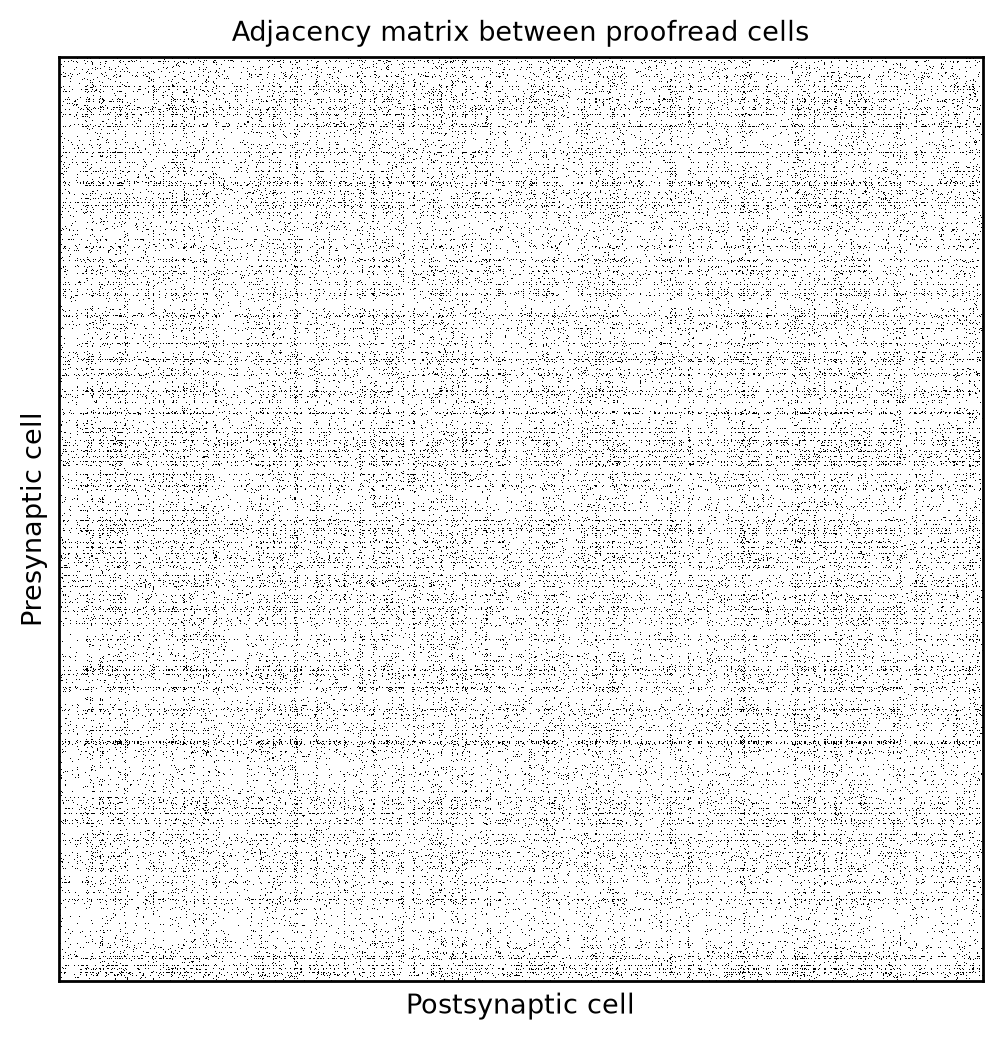

In [ ]:
sns.set_context("paper", font_scale=1.0)

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

sns.heatmap(
    syn_mat,
    cbar=False,
    cmap="Greys",
    xticklabels=False,
    yticklabels=False,
    square=True,
    ax=ax,
)
ax.spines[["left", "right", "top", "bottom"]].set_visible(True)
_ = ax.set(
    xlabel="Postsynaptic cell",
    ylabel="Presynaptic cell",
    title="Adjacency matrix between proofread cells",
)

In [ ]:
n_edges = len(row_indices)
n_possible_edges = syn_mat.shape[0] * syn_mat.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

Number of edges: 90845
Number of possible edges: 1317904
Fraction of possible edges: 0.0689


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 1: Rectangular connectivity matrix</b>
<p>The matrix visualized above only contains connections between both <b>dendrite and axon-proofread neurons</b>. Since many more dendrites of cells in the V1DD dataset are well-reconstructed, <b>we can consider more connections than just the ones between axon-proofread neurons.</b> Therefore, the connectivity matrix of analyzable connections forms a rectangular matrix instead of a square one.
<p>What is the size of the matrix between the proofread neurons and all neurons with acceptable dendrites in the dataset?

</div>

In [ ]:
# Select synapses from proofread cells onto all cells
proof_all_syn_table = filter_synapse_table(
    syn_df, pre_root_ids=axon_proof_root_ids, post_root_ids=dendrite_proof_root_ids
)

print(len(proof_all_syn_table))


1431746


In [ ]:
# make adjacency matrix from axon proofread cells onto dendrite proofread cells
rect_syn_mat = make_adjacency(
    syn_df,
    source_cell_index=axon_proof_root_ids,
    target_cell_index=dendrite_proof_root_ids,
)

# print shape of the matrix
rect_syn_mat.shape

(1164, 63986)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Consider: Different measures of synaptic strength </h3>
<p>When creating a connectivity matrix, how you measure synaptic strength can make a difference in your analysis. For EM data there are three common ways of reporting connection strength:
<ol>
<li><b>Binary connectivity:</b> whether two cells are connected at all, as shown above.
<li><b>Synaptic count:</b> the total number of synapses that are part of the connection. This is typical of the fly connectome, where <code>count</code> captures much of the connection diversity. The modal <code>count</code> in mouse cortex is much lower.
<li><b>Synaptic size:</b> the size of the postsynaptic density at every connection, generally aggregated as <code>sum</code> or <code>mean</code> for each unique connection.
</ol>
<p>How to take synapse size and number into account depends on the specific analysis.
<p>The <code>size</code> reported in the V1DD dataset measures the synaptic cleft as segmented by the automated classifier in voxels (3D pixels, a measure of volume). These are correlated to anatomical measures such as synaptic area and spine head volumes (for excitatory synapses).
<p>Let's replot the <b>square matrix</b> with the <code>sum</code> of synapse sizes between each connected pair.

</div>

In [ ]:
# get the ids of all proofread cells (same as for the binary connectivity)
proof_root_ids = axon_proof_root_ids[
    np.isin(axon_proof_root_ids, dendrite_proof_root_ids)
]

# Now with the aggregation function set to 'mean' synapse size
syn_mat = make_adjacency(syn_df, source_cell_index=proof_root_ids, aggfunc="sum")

# show the first 10 nonzero values in the array
row_indices, column_indices = np.nonzero(syn_mat)
print("Row indices:", row_indices[:10])
print("Column indices:", column_indices[:10])
print("Matrix values:", syn_mat[row_indices[:10], column_indices[:10]])

Row indices: [0 0 0 0 0 0 0 0 0 0]
Column indices: [118 234 251 262 269 275 393 423 465 579]
Matrix values: [2620  898 3828 4488 1556 4965 1436  631  270 3425]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>The matrix values are now the <b>sum of size</b> rather than <code>True</code>/<code>False</code>. It is useful to understand the full range of synaptic strength represented, plotted below first on a linear axis and then on a log axis.

</div>

[Text(0.5, 0, 'Sum synapse size (voxels - log scale)'),
 Text(0, 0.5, 'Number of connections')]

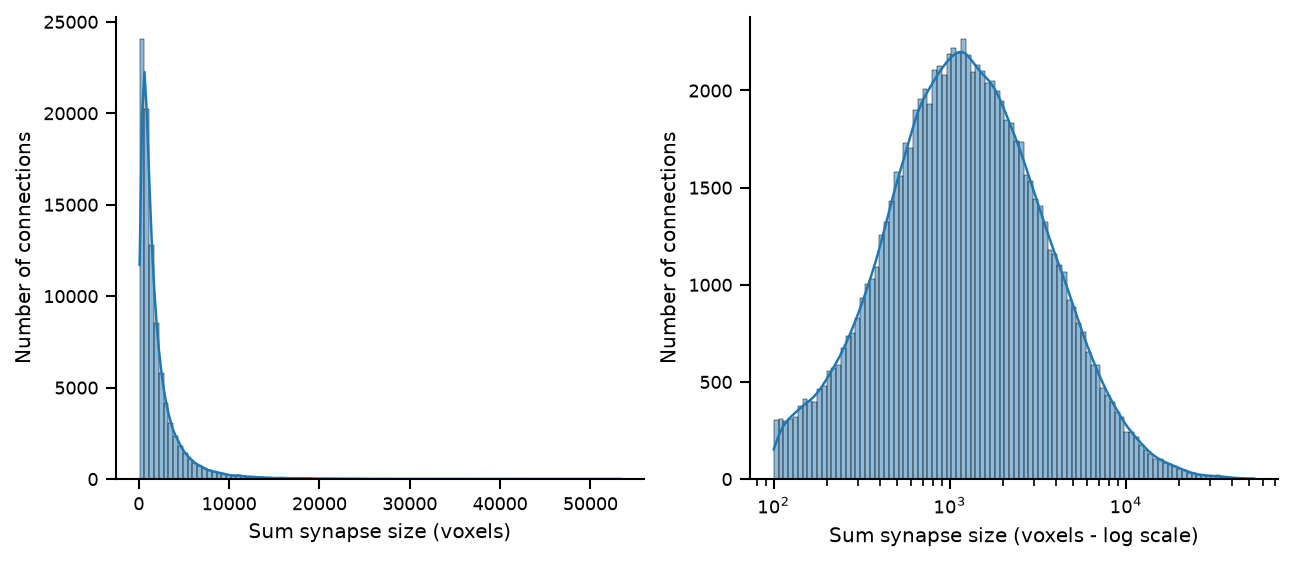

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# collect the synaptic weights that are non-zero
edge_weights = syn_mat[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(edge_weights, kde=True, bins=100, ax=ax, log_scale=True)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Replot the square matrix with the <code>sum</code> of synapse size.

</div>

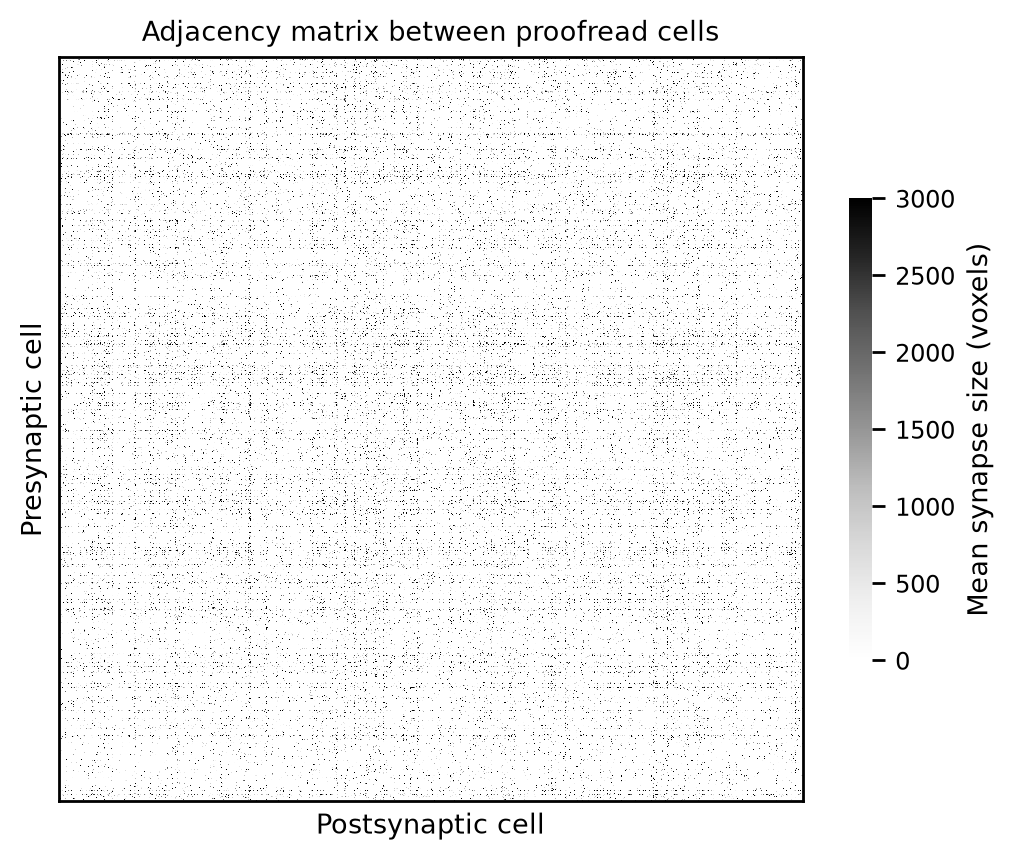

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
sns.heatmap(
    syn_mat,
    cbar=True,
    cmap="Greys",
    xticklabels=False,
    yticklabels=False,
    square=True,
    vmax=3000,  # set the upper bound on color scale so that we can see more edges
    ax=ax,
    cbar_kws={"label": "Mean synapse size (voxels)", "shrink": 0.5},
)
ax.spines[["left", "right", "top", "bottom"]].set_visible(True)
_ = ax.set(
    xlabel="Postsynaptic cell",
    ylabel="Presynaptic cell",
    title="Adjacency matrix between proofread cells",
)

In [ ]:
# horizontal streak: neuron talking to many neurons (inhibitory neurons)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Depending on the connection type, number of synapses might be the more important measure (see <a href="https://elifesciences.org/articles/76120">Dorkenwald et al., 2022</a> for a deeper dive into synapse size and counts).

</div>

[Text(0.5, 0, 'Number of synapses per connection (log scale)'),
 Text(0, 0.5, 'Number of connections')]

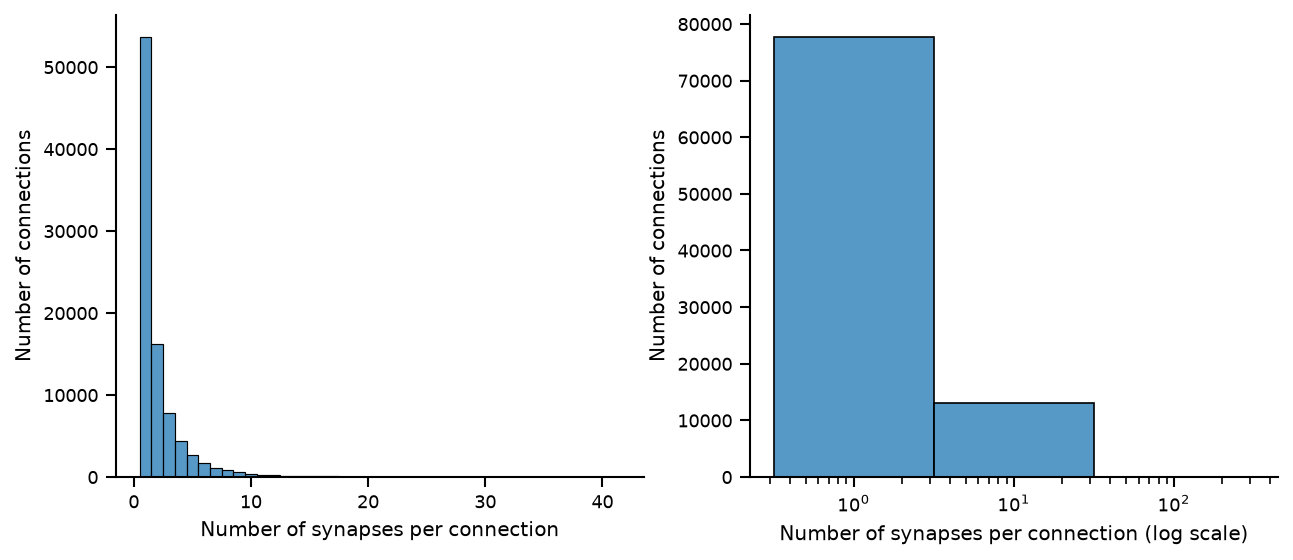

In [ ]:
# generate adjacency matrix with a count of synapses
syn_mat = make_adjacency(syn_df, proof_root_ids, aggfunc="count")

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# collect the synaptic weights that are non-zero
edge_weights = syn_mat[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Number of synapses per connection", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(edge_weights, discrete=True, ax=ax, log_scale=True)
ax.spines[["top", "right"]].set_visible(False)
ax.set(
    xlabel="Number of synapses per connection (log scale)",
    ylabel="Number of connections",
)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Next we plot the <b>number of synapses per connection</b>, or the <code>count</code>. We limit the colorbar to a maximum of 5, but the actual maximum number is much higher.

</div>

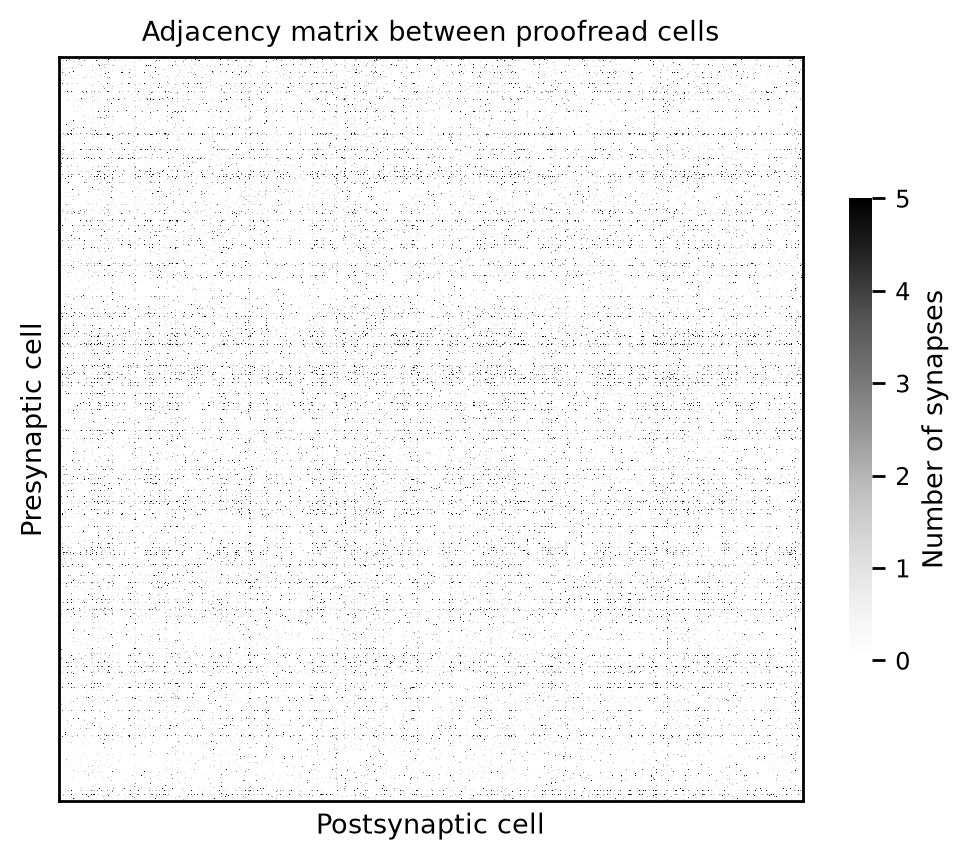

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
sns.heatmap(
    syn_mat,
    cbar=True,
    cmap="Greys",
    xticklabels=False,
    yticklabels=False,
    square=True,
    vmax=5,  # clip the color scale to 5 to see more edges
    ax=ax,
    cbar_kws={"label": "Number of synapses", "shrink": 0.5},
)
ax.spines[["left", "right", "top", "bottom"]].set_visible(True)
_ = ax.set(
    xlabel="Postsynaptic cell",
    ylabel="Presynaptic cell",
    title="Adjacency matrix between proofread cells",
)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Cell type tables </h2>
<p>Identifying the putative 'cell type' from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated 'feature classifiers' over time.
<p>Two of the most predictive features for broad cell type are:
<ul>
<li><b>Soma location</b> in units of depth from pial surface. This captures cortical layer diversity.
<li><b>Soma size</b> in units of volume. This is a strong proxy of many types of cell morphological diversity.
</ul>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Using the automated cell types </h3>
<p>Many of these automated cell type definitions were established and refined for the <a href="https://www.microns-explorer.org/">MICrONS Dataset</a>, including:
<ul>
<li>Perisomatic cell features (<a href="https://www.nature.com/articles/s41586-024-07765-7">Elabbady et al.</a>)
<li>Morphology and connectivity features (<a href="https://www.nature.com/articles/s41586-024-07780-8">Schneider-Mizell et al.</a>)
</ul>
<p>The process of applying these labels to the V1DD dataset is ongoing, but we will use cell typing from the <code>cell_type_multifeature_v1</code> table, which labels cell types using soma, nucleus, dendrite, and spine features.
<p>Excitatory neurons are labeled by projection category (IT, ET, NP, CT, and SP for subplate).
<p>Inhibitory neurons follow labels based on targeting such as ITC (inhibitory targeting), STC (sparsely targeting), PTC (perisomatic targeting), and DTC (dendrite targeting), but might align more with molecular class than exact targeting for a given neuron, particularly among ITC/VIP cells.
<p><b>QC Note: In Module 1 we queried this information from CAVE. In Module 2, this information is already aggregated in the CCM</b>. Both access patterns retrieve the same source of data, but the CCM data is limited to already 'good' cells (<code>n_soma==1</code>), those that have an interpretable dendrite.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Prepare the neuron table for to be compatible with downstream analysis.

In [ ]:
proof_cell_df = proofread_axons.select(
    pl.col("dataitem_id").cast(pl.UInt64).alias("pt_root_id"),
    pl.col("soma_voxel_x").alias("pt_position_x"),
    pl.col("soma_voxel_y").alias("pt_position_y"),
    pl.col("soma_voxel_z").alias("pt_position_z"),
    pl.col("soma_transformed_x").alias("pt_position_trform_x"),  # already um
    pl.col("soma_transformed_y").alias("pt_position_trform_y"),  # already um
    pl.col("soma_transformed_z").alias("pt_position_trform_z"),  # already um
    pl.col("soma_volume").alias("volume"),
    pl.col("v1dd_cell_types_level_1").alias("cell_type_coarse"),
    pl.col("v1dd_cell_types_level_2").alias("cell_type"),
).to_pandas()

# Filter the cell type table for those with a proofread root id and non-null cell types
proof_cell_df = proof_cell_df.set_index("pt_root_id").loc[proof_root_ids]
proof_cell_df = proof_cell_df.query("cell_type.notna()")

proof_cell_df.head()

,pt_position_x,pt_position_y,pt_position_z,pt_position_trform_x,pt_position_trform_y,pt_position_trform_z,volume,cell_type_coarse,cell_type
pt_root_id,,,,,,,,,
864691132534275418,739373.0,633371.0,323640.0,-148.078156,332.191132,39.439651,224.683212,E,L4-IT
864691132534315610,823103.0,635932.0,272970.0,-62.355999,320.556305,-10.523945,236.639908,E,L4-IT
864691132535664474,972173.0,1006782.0,429480.0,-41.442623,739.148865,7.655986,300.366089,E,L6-CT
864691132536286810,860041.0,818137.0,270495.0,-66.701279,499.937653,-63.436977,278.909668,I,DTC
864691132536904794,940822.0,738674.0,146565.0,41.854176,385.942078,-158.125732,273.808777,I,DTC


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Sorting the synapse matrix with cell features and types </h2>
<p>Let's combine the synaptic connectivity with the cell type information. Below we provide logic for sorting a connectivity matrix using a list of labels.

<p> Let's first sort by <b>soma depth</b>. Remember that the transformed y axis is aligned with the cortical pia-to-white matter axis.

</div>

In [ ]:
# Sort it by soma depth
proof_cell_df = proof_cell_df.sort_values("pt_position_trform_y")

# Make adjacency, now including soma depth and cell type
syn_mat = make_adjacency(syn_df, proof_cell_df, aggfunc="sum")
syn_mat

array([[  0,   0, 274, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(1124, 1124))

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p><b>Note:</b> There are slightly fewer cells in this adjacency matrix because we are filtering for cells that have complete information in the cell table above.

</div>

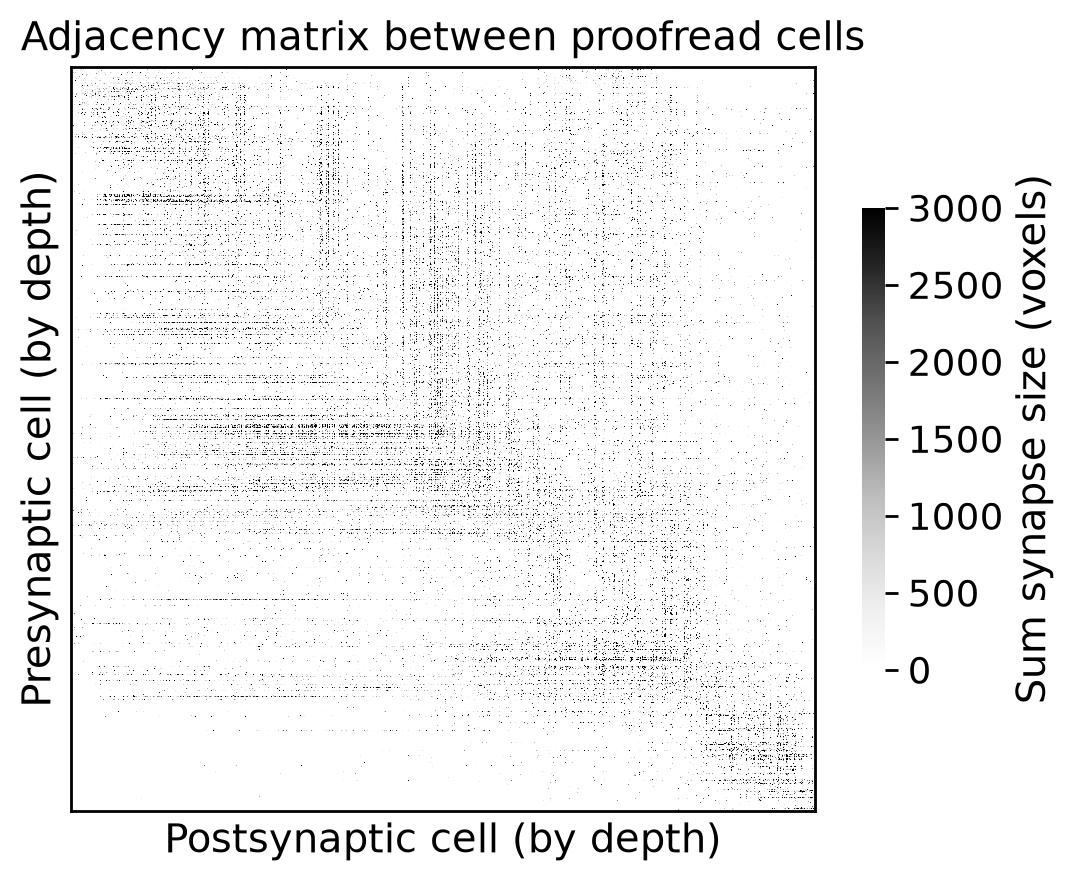

In [ ]:
sns.set_context("paper", font_scale=1.5)
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
sns.heatmap(
    syn_mat,
    cbar=True,
    cmap="Greys",
    xticklabels=False,
    yticklabels=False,
    square=True,
    vmax=3000,
    ax=ax,
    cbar_kws={"label": r"Sum synapse size (voxels)", "shrink": 0.5},
)
ax.spines[["left", "right", "top", "bottom"]].set_visible(True)
_ = ax.set(
    xlabel="Postsynaptic cell (by depth)",
    ylabel="Presynaptic cell (by depth)",
    title="Adjacency matrix between proofread cells",
)

In [ ]:
# neurons in the same depath tend to connect together
# Deep neurons tend to connect by themseleves
# Shallow neurons tend to connect neurons with various depth

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 2: Interpret connectivity by depth</b>
<p>There is a large amount of structure in the connectivity just based on soma depth. However, some rows are very narrow in their connectivity while others are very wide.
<p><b>Discussion</b>
<p>What are some explanations for why the connectivity plot has a strong diagonal component? In contrast, what does the wide connectivity in a row or column mean?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Add cell type logic to the adjacency plot </h2>
<p>What about the effect of cell types on the connectivity matrix? We can add colors and subplots by cell type to make this matrix more tractable. We have packaged away the logic for this in <code>utils.adjacencyplot</code>, which can group and sort the adjacency matrix by metadata in the cell table.
<p>The logic here is similar to the plotting package <code>seaborn</code>, where different labels within the data can be leveraged to control different elements.

</div>

(<Axes: >, <utils.AxisGrid at 0x7fd37bbc0a10>)

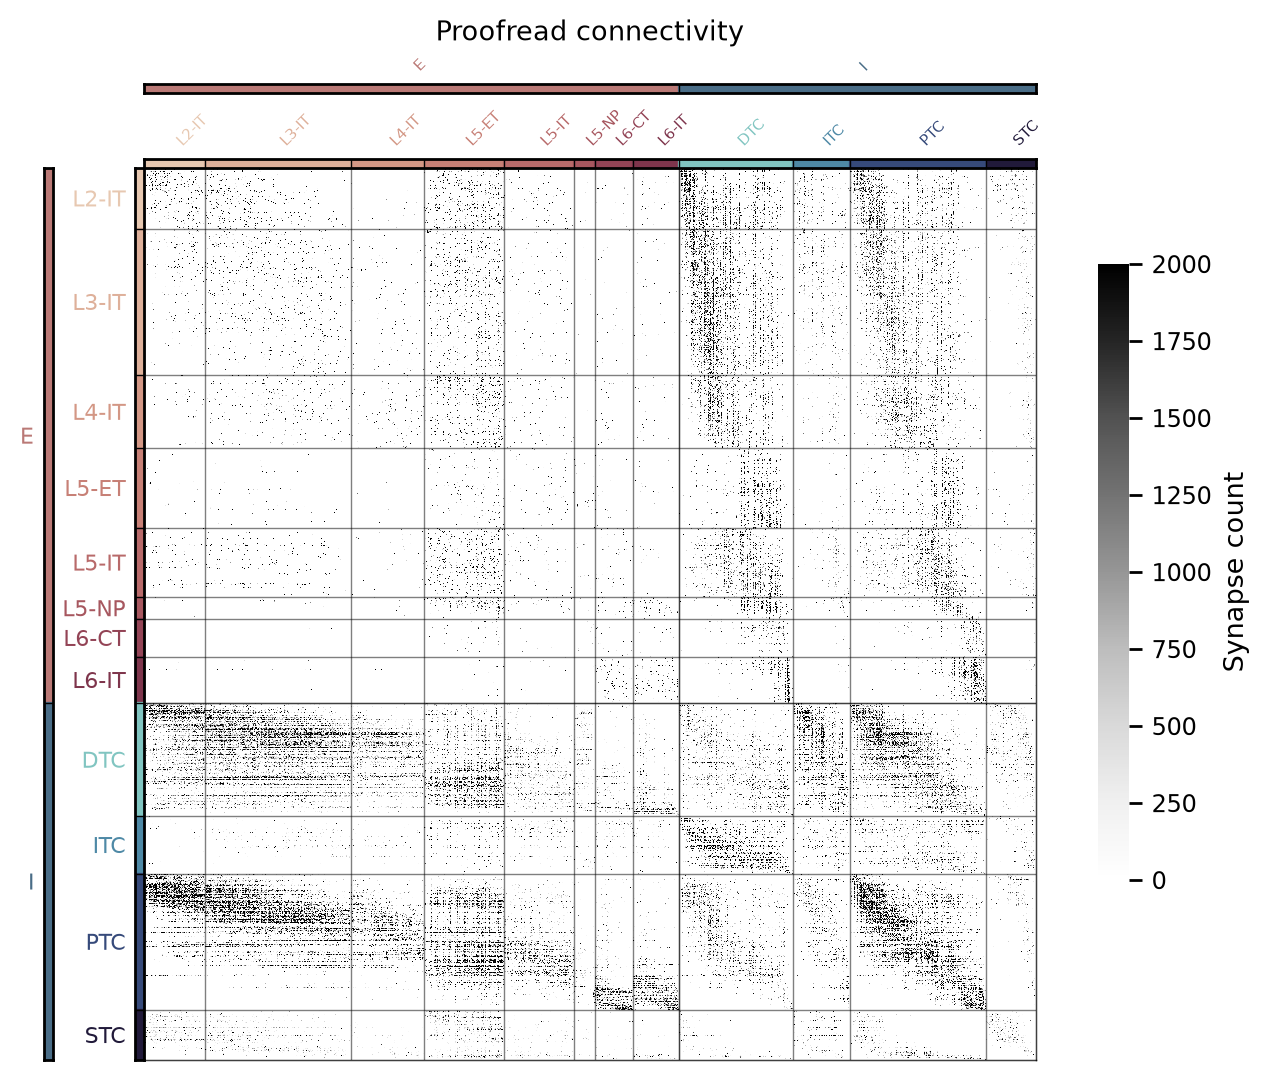

In [ ]:
from utils import adjacencyplot, cell_type_palette

sns.set_context("paper", font_scale=1.0)

fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

# render the adjacency plot
adjacencyplot(
    syn_mat,  # data values for the points
    nodes=proof_cell_df,  # data to organize the x and y axis
    groupby=["cell_type_coarse", "cell_type"],  # categorical variables to organize by
    sortby="pt_position_y",  # sort within groups by variable
    node_palette=cell_type_palette,
    title="Proofread connectivity",
    edge_palette="Greys",
    hue_norm=(0, 2000),  # normalize the color scale for the edges
    ax=ax,
    label_fontsize="xx-small",
    title_fontsize="medium",
    arc_labels=False,
)

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 3: Identify a cell in the connectivity matrix</b>
<p>Now we have restructured the connectivity based on cell type. Find one of your example cells from this morning and identify its row or column. Hint: query <code>proof_cell_df</code> by your <code>root_id</code>.
<p><b>Discussion</b>
<p>Describe the connectivity for your cell by who it targets and who it receives inputs from.
<p>Then, for each row, describe that cell type by its major targets. Do you think there are more subgroups within the cell types?

</div>

In [ ]:
# Query the cell type of your root_id:
root_id = 864691132534315610  # Known example neuron. You may iterate

# Your code here

proof_cell_df.query(f"pt_root_id=={root_id}")[["cell_type_coarse", "cell_type"]]

,cell_type_coarse,cell_type
pt_root_id,,
864691132534315610,E,L4-IT


<hr style="height: 4px; background: #000; border: none;">

<h2 align="center">Coffee break</h2>

<p align="center">After the break we pick up a different question &mdash; whether the <i>connectivity</i> of neurons tells us anything about how <i>correlated</i> their <i>function is</i>.</p>

<hr style="height: 4px; background: #000; border: none;">

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1> Connectomics Module 2b: Connectivity principles and structure–function </h1>
<p>What predicts whether any two neurons are connected, when we look past cell type to <b>where the neurons are</b> and <b>what they do</b>?
<p>We test two candidate rules, and then ask whether they are redundant:
<ol>
<li><b>Part 1 — Space.</b> Are nearby neurons more likely to be connected?
<li><b>Part 2 — Function.</b> Are co-active neurons more likely to be connected?
<li><b>Part 3 — A stronger null model.</b> Distance and co-activity are themselves related, so we ask whether either one tells us anything about connectivity that the other does not.
</ol>
<p>Throughout we work with <b>L3-IT</b> pyramidal cells, the excitatory population with the most proofread axons in V1DD. Fixing the cell type at first makes the analysis more tractable.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Intro

### Loading the data
<p>We work with the two V1DD datasets below:

1. Part 1: `v1dd_1196_ccm` through the Common Connectivity store as above. Contains cells, cell types and synapses.
2. Part 2 & 3: combine part 1 with functional data, `cell_cell_correlations_by_stimulus_coregistered.feather`, containing pairwise correlation of coregistered calcium responses across stimulus types.
   
The Common Connectivity store, its <code>DatasetReader</code> and <code>read_synapse_table</code> are already used above. See also <a href="../supplement/etl_v1dd_01_cave_dataset_celltypes.ipynb">supplement/etl_v1dd_*.ipynb</a>.

</div>

In [ ]:
reader = DatasetReader(ccm_dir)

reader.display_dataset_names()

id,name,project_id,modality
str,str,str,str
"""v1dd_1196_em""","""V1DD release 1196 — EM somas""","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_axons""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_dendrites""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""


In [ ]:
proofread_axons = reader.read_dataset(axon_dataset_id)
proofread_dendrites = reader.read_dataset(dendrite_dataset_id)

axon_proof_root_ids = proofread_axons["dataitem_id"].cast(pl.UInt64).to_numpy()
dendrite_proof_root_ids = proofread_dendrites["dataitem_id"].cast(pl.UInt64).to_numpy()

print(f"{len(axon_proof_root_ids):>6,} cells with proofread axons")
print(f"{len(dendrite_proof_root_ids):>6,} cells with acceptable dendrites")
print(
    f"{np.isin(axon_proof_root_ids, dendrite_proof_root_ids).sum():>6,} cells with both"
)

proofread_dendrites.head(3)

 1,164 cells with proofread axons
63,986 cells with acceptable dendrites
 1,148 cells with both


dataitem_id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,soma_area_to_volume_ratio,soma_synapse_density_um,soma_voxel_x,soma_voxel_y,soma_voxel_z,soma_transformed_x,soma_transformed_y,soma_transformed_z,soma_volume,v1dd_cell_types_level_0,v1dd_cell_types_level_1,v1dd_cell_types_level_2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,str,str,str
"""864691132496108732""",153.714823,262.44489,1.891226,87.028684,0.331607,0.52135,294.840211,292.666366,1.613731,1.366147,0.068337,1.65513e6,605358.0,776205.0,747.656006,423.467957,484.288116,153.827026,null,null,null
"""864691132511800666""",257.461754,283.770235,1.44991,42.661132,0.150337,0.968305,265.88904,281.628224,0.120611,1.408397,0.014203,1.227399e6,659134.0,270000.0,338.375732,340.317505,-18.48254,257.700134,null,null,null
"""864691132525163794""",258.152734,266.504962,1.359263,38.271973,0.143607,0.427513,603.847392,767.669205,0.686228,2.221972,0.087277,1.546956e6,533345.0,771210.0,655.235413,351.830109,498.754974,258.204437,null,null,null


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Cell coordinate systems </h3>

<p>Two coordinate systems are commonly used:
<ul>
<li><code>soma_voxel_*</code> — the raw EM coordinates. Use these to look a neuron up in Neuroglancer.
<li><code>soma_transformed_*</code> — the same somas after rotating the pial surface flat and anchoring it to y = 0, in <b>µm</b>. The volume was not imaged perfectly upright, so only in these coordinates does "y" mean cortical depth and "x, z" mean tangential position. Use these for most geometric.
</ul>

</div>

In [ ]:
cell_df = proofread_dendrites.select(
    pl.col("dataitem_id").cast(pl.UInt64).alias("pt_root_id"),
    # transformed coordinates, already in µm
    pl.col("soma_transformed_x").alias("pt_position_trform_x"),
    pl.col("soma_transformed_y").alias("pt_position_trform_y"),
    pl.col("soma_transformed_z").alias("pt_position_trform_z"),
    pl.col("soma_volume").alias("volume"),
    pl.col("v1dd_cell_types_level_1").alias("cell_type_coarse"),
    pl.col("v1dd_cell_types_level_2").alias("cell_type"),
).to_pandas()

cell_df.head(3)

,pt_root_id,pt_position_trform_x,pt_position_trform_y,pt_position_trform_z,volume,cell_type_coarse,cell_type
0,864691132496108732,747.656006,423.467957,484.288116,153.827026,None,None
1,864691132511800666,338.375732,340.317505,-18.482540,257.700134,None,None
2,864691132525163794,655.235413,351.830109,498.754974,258.204437,None,None


In [ ]:
cell_df["cell_type"].value_counts()

cell_type
L6-CT    11260
L4-IT     7955
L3-IT     6361
L6-IT     6044
L5-IT     5090
L2-IT     3073
PTC       2951
L5-ET     2013
DTC       1933
ITC       1090
STC        723
L5-NP      699
Name: count, dtype: int64

In [ ]:
synapse_data = read_synapse_table(
    project_id,
    dataset_id=synapse_dataset_id,
    features=True,
    feature_matrix_id=synapse_feature_matrix_id,
    output_root=ccm_dir,
)

syn_df = (
    synapse_data.with_columns(
        pl.col("id").cast(pl.UInt64),
        pl.col("presynaptic_cell").cast(pl.UInt64),
        pl.col("postsynaptic_cell").cast(pl.UInt64),
    )
    .rename(
        {
            "presynaptic_cell": "pre_pt_root_id",
            "postsynaptic_cell": "post_pt_root_id",
        }
    )
    .select(["id", "pre_pt_root_id", "post_pt_root_id", "size"])
    .to_pandas()
)

print(f"{len(syn_df):,} synapses")
syn_df.head(3)

8,204,497 synapses


,id,pre_pt_root_id,post_pt_root_id,size
0,354386968,864691132536286810,864691132734919083,240
1,378070488,864691132572190492,864691132606767301,3056
2,499493001,864691132573738810,864691132747578447,1346


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Part 1: Distance vs. connection probability </h2>
<p><b>Why expect distance to matter at all?</b> A synapse can only form where an axon and a dendrite physically touch. Both arbors are finite — a cortical pyramidal cell's dendrites span a couple of hundred µm, its local axon somewhat more — so two neurons far apart in the tangential plane simply have less opportunity to meet. Wiring also costs the animal volume, metabolism and conduction delay, all of which push toward local connections. The strong version of this idea, that connection probability follows arbor overlap and nothing else, is known as <b>Peters' rule</b>.
<p>We compare the distance distribution of <i>all</i> L3-IT pairs against the distance distribution of <i>connected</i> L3-IT pairs.

</div>

In [ ]:
sub_cell_df = cell_df[cell_df["cell_type"] == "L3-IT"]

print(f"{len(sub_cell_df)} L3-IT cells")

6361 L3-IT cells


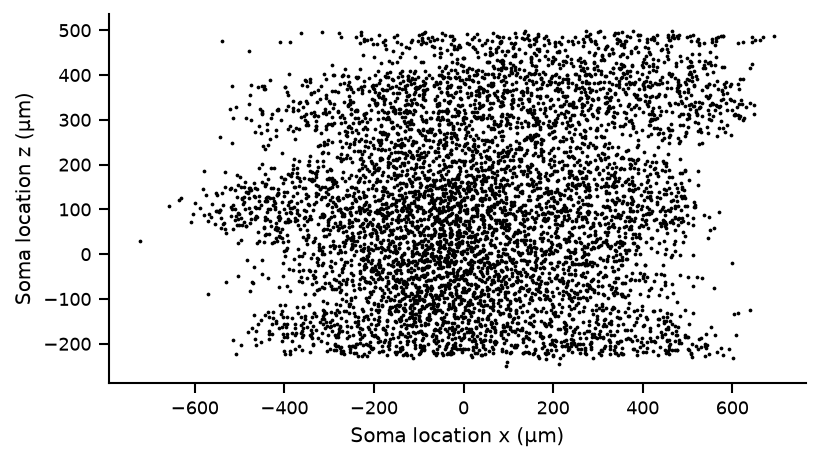

In [ ]:
# Figure 1: Soma positions of all L3-IT cells, viewed from the top (tangential plane)

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ax.scatter(
    data=sub_cell_df, x="pt_position_trform_x", y="pt_position_trform_z", c="k", s=1
)

ax.set(xlabel="Soma location x (µm)", ylabel="Soma location z (µm)", aspect="equal")
sns.despine()
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 4</b> Are the proofread neurons evenly distributed through the volume? Filter <code>sub_cell_df</code> to cells with proofread axons and plot them on top of all L3-IT somas.
<p><i>Hint:</i> <code>np.isin</code> keeps the ids that are also in <code>axon_proof_root_ids</code>.

</div>

In [ ]:
proof_cell_df

,pt_position_x,pt_position_y,pt_position_z,pt_position_trform_x,pt_position_trform_y,pt_position_trform_z,volume,cell_type_coarse,cell_type
pt_root_id,,,,,,,,,
864691132893609430,750625.0,340897.0,198675.0,-95.137909,8.625561,-61.295742,338.523193,I,STC
864691132669631318,826595.0,342682.0,242640.0,-20.992805,22.108572,-16.730764,293.127136,I,STC
864691132782725463,764748.0,329490.0,295920.0,-83.137238,24.026770,38.482433,272.112152,I,STC
864691132645566078,729362.0,369066.0,162810.0,-118.802757,26.786856,-99.829147,359.267761,I,STC
864691132806341890,810765.0,350907.0,276210.0,-39.213703,39.632927,16.948704,258.485443,I,STC
...,...,...,...,...,...,...,...,...,...
864691132734015767,944470.0,1031925.0,479340.0,-85.254112,780.087524,42.263096,295.345642,E,L6-CT
864691132980861372,963171.0,1048764.0,422910.0,-66.945099,781.201599,-16.790745,443.307617,I,PTC
864691132835856021,936322.0,1038443.0,477540.0,-95.859871,786.429077,37.706490,304.922882,E,L6-CT


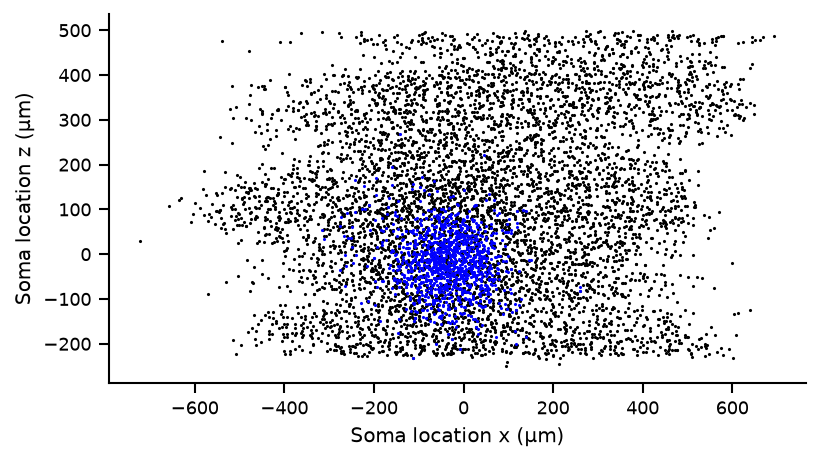

In [ ]:
# Figure 1: Soma positions of all L3-IT cells, viewed from the top (tangential plane)

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ax.scatter(
    data=sub_cell_df, x="pt_position_trform_x", y="pt_position_trform_z", c="k", s=0.5
)

ax.scatter(
    data=proof_cell_df, x="pt_position_trform_x", y="pt_position_trform_z", c="b", s=0.5, 
)

ax.set(xlabel="Soma location x (µm)", ylabel="Soma location z (µm)", aspect="equal")
sns.despine()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Lateral distance between somas </h3>
<p>We use <i>lateral</i> distance — the distance in the tangential (x, z) plane, ignoring cortical depth. Two reasons, one biological and one statistical. Biologically, depth <i>is</i> layer, and layer is cell type: a neuron 300 µm below another is in a different layer and belongs to a different population with different partners, which is a different effect from being 300 µm to the side. Statistically, we already fixed cell type by taking L3-IT alone, so the remaining depth spread is thin and mostly reflects where in L3 a soma sits. Collapsing it gives us the quantity we actually mean by "nearby in the cortical sheet".
<p>For one pair it is just a vector norm:

</div>

In [ ]:
pos_cols = ["pt_position_trform_x", "pt_position_trform_z"] #because lateral distance; tangential (x,z) plane

difference = sub_cell_df.iloc[0][pos_cols] - sub_cell_df.iloc[1][pos_cols]
np.linalg.norm(difference) # square root

np.float32(393.98657)

In [ ]:
difference

pt_position_trform_x   -380.564209
pt_position_trform_z   -101.962326
dtype: object

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>And for all pairs at once with <code>scipy.spatial.distance.cdist</code>:

</div>

In [ ]:
def calculate_lateral_distances(pre_cell_df, post_cell_df=None):
    """Calculates the lateral distances in µm between all neurons."""
    if post_cell_df is None:
        post_cell_df = pre_cell_df

    pre_lateral_locations = np.array(
        pre_cell_df[["pt_position_trform_x", "pt_position_trform_z"]]
    )
    post_lateral_locations = np.array(
        post_cell_df[["pt_position_trform_x", "pt_position_trform_z"]]
    )
    lateral_distances = spatial.distance.cdist(
        pre_lateral_locations, post_lateral_locations
    )

    id_pairs = list(
        itertools.product(pre_cell_df["pt_root_id"], post_cell_df["pt_root_id"])
    )

    # Root ids stay uint64. Merging a uint64 column against an int64 one casts both to
    # float64, and ids this large (~9e17) are past the range float64 represents exactly, so
    # distinct cells would silently collide.
    lateral_distance_df = pd.DataFrame(
        id_pairs, columns=["pre_pt_root_id", "post_pt_root_id"]
    ).astype({"pre_pt_root_id": np.uint64, "post_pt_root_id": np.uint64})
    lateral_distance_df["distance"] = lateral_distances.flatten()

    # drop self-pairs
    lateral_distance_df = lateral_distance_df[
        lateral_distance_df["pre_pt_root_id"] != lateral_distance_df["post_pt_root_id"]
    ]
    return lateral_distance_df

<div style="border-left: 3px solid #B8860B; padding: 1px; padding-left: 10px; background: #FFF8DC; ">

<p><b>The next cell takes about a minute.</b> It computes the distance between every pair of cells, so the work grows with the square of the cohort size.

</div>

In [ ]:
lateral_distance_df = calculate_lateral_distances(sub_cell_df)

lateral_distance_df.head(3)

,pre_pt_root_id,post_pt_root_id,distance
1,864691132533643098,864691132533648218,393.986590
2,864691132533643098,864691132533665626,530.098968
3,864691132533643098,864691132533673818,377.014864


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### Lateral distance between all pairs and proofread pairs
<p>The distribution above covers <i>all</i> L3-IT pairs. But we are about to count how often pairs are connected, and for that a pair is only <b>testable</b> if the presynaptic cell has a proofread axon and the postsynaptic cell an acceptable dendrite.
<p>This is worth pausing on, because it is the trap that catches most people using a connectome for the first time. If an axon was never traced to its end, the synapses on its missing branches are missing from the table too. Counting those pairs as "not connected" would mix two different statements — <i>we looked and there is no synapse</i> and <i>we did not finish looking</i> — and the second is far more common.

Note: to know whether a pair of cells is connected, it is not necessary that both have both dendrites and axons proofread, which is an even smaller amount of cells.

</div>

In [ ]:
# Gathering proofread L3-IT IDs
pre_root_ids = sub_cell_df["pt_root_id"][
    np.isin(sub_cell_df["pt_root_id"], axon_proof_root_ids)
]
post_root_ids = sub_cell_df["pt_root_id"][
    np.isin(sub_cell_df["pt_root_id"], dendrite_proof_root_ids)
]

lateral_distance_proofread_df = lateral_distance_df[
    np.isin(lateral_distance_df["pre_pt_root_id"], pre_root_ids)
    & np.isin(lateral_distance_df["post_pt_root_id"], post_root_ids)
]

print(f"{len(lateral_distance_df):>9,} L3-IT pairs")
print(f"{len(lateral_distance_proofread_df):>9,} testable (proofread) L3-IT pairs")

40,455,960 L3-IT pairs
1,176,600 testable (proofread) L3-IT pairs


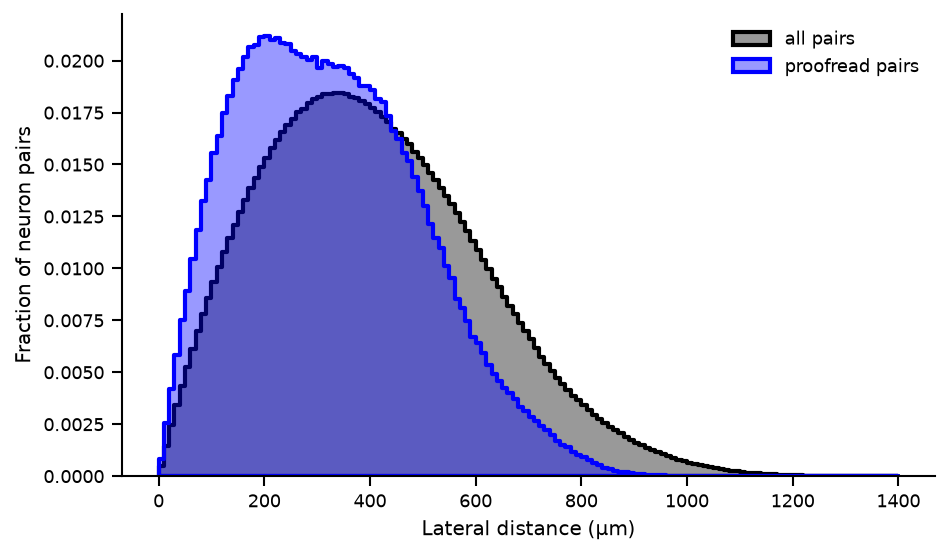

In [ ]:
# Figure 2: Distance distribution, all pairs vs. testable pairs

bins = np.linspace(0, 1400, 141)

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

for df, color, label in [
    (lateral_distance_df, "k", "all pairs"),
    (lateral_distance_proofread_df, "b", "proofread pairs"),
]:
    sns.histplot(
        df,
        x="distance",
        stat="proportion",
        bins=bins,
        element="step",
        fill=True,
        alpha=0.4,
        lw=2,
        color=color,
        label=label,
        ax=ax,
    )

ax.legend(frameon=False)
ax.set(xlabel="Lateral distance (µm)", ylabel="Fraction of neuron pairs")
sns.despine()
plt.show()

### Interlude: is a difference between two distributions real?

We just eyeballed two histograms and said one is shifted. Every comparison in this module
is of that form, so it is worth setting up the machinery once.

**The definition.** A **null hypothesis** $H_0$ is a specific claim that nothing
interesting is going on — here, *the two samples are drawn from the same distribution*.
Choose a **test statistic** $T$ whose large values would be surprising under $H_0$, observe
its value $t_{\text{obs}}$, and report

$$p \;=\; \Pr\!\left(T \ge t_{\text{obs}} \;\middle|\; H_0\right).$$

That is: *if the null were true, how often would we see a statistic at least this extreme?*
A small $p$ means the data would be unusual under $H_0$, so $H_0$ is a poor explanation.

Two things $p$ is **not**. It is not the probability that $H_0$ is true — that quantity is
not even defined in this framework, which assigns no probability to hypotheses. And it says
nothing about how *large* the effect is: with enough data, a difference too small to care
about still gets a tiny $p$. Effect size is a separate question, and we report one alongside
every $p$ below.

*(Casella & Berger, [Statistical Inference](https://www.cengage.com/c/statistical-inference-2e-casella/), 2nd ed., §8.3.4 gives the formal definition;
Wasserman, [All of Statistics](https://link.springer.com/book/10.1007/978-0-387-21736-9), §10.2 is a compact treatment.)*

**The test.** Our distributions are skewed and the two groups differ wildly in size, so we
use the **Mann–Whitney U test** rather than anything assuming normality. It ranks all the
values together and counts how often a draw from one group beats a draw from the other:

$$U \;=\; \#\{(i,j) : x_i > y_j\} \;+\; \tfrac{1}{2}\,\#\{(i,j) : x_i = y_j\},
\qquad \mathrm{AUC} \;=\; \frac{U}{n_x n_y}.$$

The two samples are $x_1 \dots x_{n_x}$ and $y_1 \dots y_{n_y}$, so $n_x n_y$ is the
number of head-to-head comparisons available. $U$ counts how many of them the first sample
wins — the number of comparisons with $x_i \ge y_j$, awarding a full point for a win and
half a point for a tie, since a tie favours neither side and splitting it evenly leaves the
statistic unbiased.

$H_0$ is that a random $x$ is equally likely to fall above or below a random $y$, so
$\mathrm{AUC} = 0.5$. That normalised $U$ is the effect size we want, and it has a plain
reading: **the probability that a random member of the first group exceeds a random member
of the second.** 0.5 is no difference, 1.0 is perfect separation.
*(Mann & Whitney, [Ann. Math. Statist. 18:50–60, 1947](https://doi.org/10.1214/aoms/1177730491).)*

In [ ]:
def compare_distributions(sample_a, sample_b, name_a="a", name_b="b"):
    """Mann-Whitney U test between two samples, with its effect size.

    Returns (p, auc), where auc is the probability that a random draw from
    `sample_a` exceeds a random draw from `sample_b`. 0.5 means no difference.
    """
    sample_a = np.asarray(sample_a)
    sample_b = np.asarray(sample_b)
    u, p = stats.mannwhitneyu(sample_a, sample_b, alternative="two-sided")
    auc = u / (len(sample_a) * len(sample_b))

    # scipy's normal approximation underflows to exactly 0.0 far enough into the tail,
    # and a p-value of 0 is not a real quantity. Report the precision limit instead.
    p_text = f"{p:.3g}" if p > 0 else "<1e-300"

    print(f"{name_a} (n={len(sample_a):,})  vs  {name_b} (n={len(sample_b):,})")
    print(
        f"  median      {np.median(sample_a):>10.4g}  vs {np.median(sample_b):>10.4g}"
    )
    print(f"  p           {p_text:>10}")
    print(f"  AUC         {auc:>10.3f}   (0.5 = indistinguishable)")
    print(f"     a random '{name_a}' exceeds a random '{name_b}' {auc:.1%} of the time")
    return p, auc

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Applied to Figure 2 — and note we compare the testable pairs against the ones we <i>cannot</i> test, rather than against all pairs, since the testable set is part of "all" and a nested comparison would dilute exactly the difference we are asking about.

</div>

In [ ]:
untestable_distances = lateral_distance_df.loc[
    ~lateral_distance_df.index.isin(lateral_distance_proofread_df.index), "distance"
]

p, auc = compare_distributions(
    lateral_distance_proofread_df["distance"],
    untestable_distances,
    "testable pairs",
    "untestable pairs",
)

testable pairs (n=1,176,600)  vs  untestable pairs (n=39,279,360)
  median           312.9  vs      390.4
  p              <1e-300
  AUC              0.387   (0.5 = indistinguishable)
     a random 'testable pairs' exceeds a random 'untestable pairs' 38.7% of the time


So proofreading really did bias which pairs we can test toward shorter separations. That is
a fact about the dataset, not about the brain — and it is the reason every comparison from
here on stays inside the testable set.

Two details worth noticing in that output. The $p$-value **underflows**: with 39 million
comparisons the statistic is so far into the tail that the normal approximation returns
exactly `0.0` in double precision. Zero is not a probability any finite computation can
establish, so the helper reports `<1e-300`. And with $n$ this large, $p$ has stopped being
informative at all — *any* difference, however trivial, would be "significant". The AUC is
the number that still carries meaning.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Lateral distance between connected pairs </h3>
<p>Now the connected pairs. We filter the synapse table down to the testable L3-IT pairs, then collapse multi-synaptic connections: a pair joined by four synapses is still <i>one</i> connection, with a summed synapse size.

</div>

In [ ]:
analysis_syn_df = filter_synapse_table(syn_df, pre_root_ids, post_root_ids).reset_index(
    drop=True
)

conn_df = (
    analysis_syn_df.groupby(["pre_pt_root_id", "post_pt_root_id"])["size"]
    .sum()
    .reset_index()
)

print(f"{len(analysis_syn_df):,} synapses -> {len(conn_df):,} unique connections")
conn_df.head(3)

10,316 synapses -> 9,655 unique connections


,pre_pt_root_id,post_pt_root_id,size
0,864691132548503618,864691132543938961,2388
1,864691132548503618,864691132569612060,2471
2,864691132548503618,864691132574630714,3758


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 5</b> For each connection we want the distance between the two neurons. Write the <code>pd.merge</code> that combines <code>conn_df</code> and <code>lateral_distance_df</code> into <code>conn_dist_df</code>. The connectivity table is much smaller than the distance table, so the merge doubles as a filter: it keeps only the pairs that are connected.
<p><i>Hint:</i> <code>pd.merge</code> can merge on several columns at once.

</div>

In [ ]:
conn_df

,pre_pt_root_id,post_pt_root_id,size
0,864691132548503618,864691132543938961,2388
1,864691132548503618,864691132569612060,2471
2,864691132548503618,864691132574630714,3758
3,864691132548503618,864691132578853908,4049
4,864691132548503618,864691132579802898,405
...,...,...,...
9650,864691133312850768,864691132920902369,2178
9651,864691133312850768,864691132951373898,2810
9652,864691133312850768,864691132959723367,3439
9653,864691133312850768,864691133028981458,3220


In [ ]:
lateral_distance_df

,pre_pt_root_id,post_pt_root_id,distance
1,864691132533643098,864691132533648218,393.986590
2,864691132533643098,864691132533665626,530.098968
3,864691132533643098,864691132533673818,377.014864
4,864691132533643098,864691132533687130,465.719955
5,864691132533643098,864691132533689434,71.707492
...,...,...,...
40462315,864691133313559888,864691133310632272,534.332454
40462316,864691133313559888,864691133311779152,110.710007
40462317,864691133313559888,864691133311977552,373.264279
40462318,864691133313559888,864691133312850768,205.754403


In [ ]:
conn_dist_df = pd.merge(conn_df, lateral_distance_df, on = ('pre_pt_root_id', 'post_pt_root_id') )

In [ ]:
conn_dist_df.shape, conn_df.shape, lateral_distance_df.shape

((9655, 4), (9655, 3), (40455960, 3))

In [ ]:
conn_dist_df

,pre_pt_root_id,post_pt_root_id,size,distance
0,864691132548503618,864691132543938961,2388,26.568672
1,864691132548503618,864691132569612060,2471,358.268604
2,864691132548503618,864691132574630714,3758,59.130357
3,864691132548503618,864691132578853908,4049,127.217264
4,864691132548503618,864691132579802898,405,53.655995
...,...,...,...,...
9650,864691133312850768,864691132920902369,2178,80.630580
9651,864691133312850768,864691132951373898,2810,94.312362
9652,864691133312850768,864691132959723367,3439,155.198224
9653,864691133312850768,864691133028981458,3220,42.524411


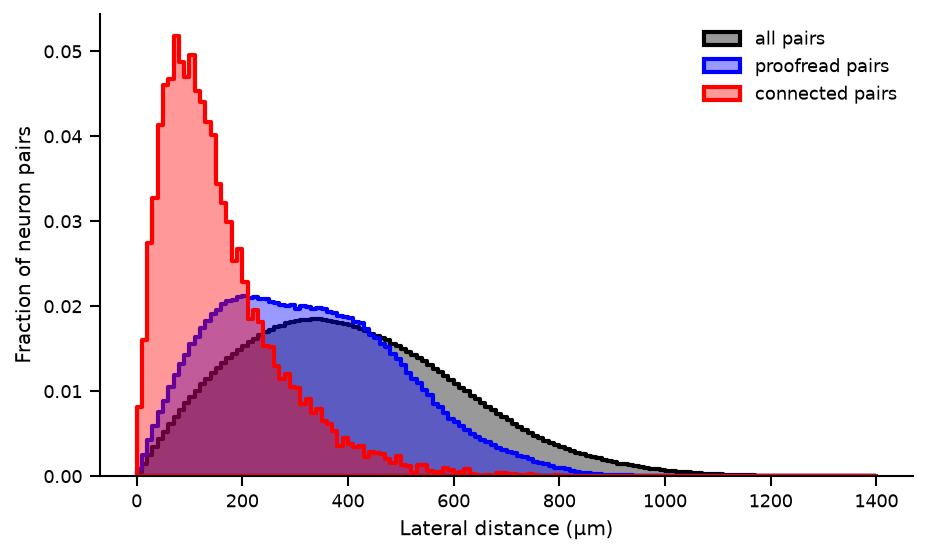

In [ ]:
# Figure 3: Connected pairs are shifted toward short distances

bins = np.linspace(0, 1400, 141)

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

for df, color, label in [
    (lateral_distance_df, "k", "all pairs"),
    (lateral_distance_proofread_df, "b", "proofread pairs"),
    (conn_dist_df, "r", "connected pairs"),
]:
    sns.histplot(
        df,
        x="distance",
        stat="proportion",
        bins=bins,
        element="step",
        fill=True,
        alpha=0.4,
        lw=2,
        color=color,
        label=label,
        ax=ax,
    )

ax.legend(frameon=False)
ax.set(xlabel="Lateral distance (µm)", ylabel="Fraction of neuron pairs")
sns.despine()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Now the comparison that carries Part 1's claim: among pairs we can test, are the connected ones closer together?

</div>

In [ ]:
# create the unique set of (pre, post) pairs
connected_keys = set(
    map(tuple, conn_dist_df[["pre_pt_root_id", "post_pt_root_id"]].values)
)
# create a connection filter across all possible pairs (from the pairwise distance computation)
is_connected = np.array(
    [
        key in connected_keys
        for key in map(
            tuple,
            lateral_distance_proofread_df[["pre_pt_root_id", "post_pt_root_id"]].values,
        )
    ]
)

p, auc = compare_distributions(
    lateral_distance_proofread_df["distance"][is_connected],
    lateral_distance_proofread_df["distance"][~is_connected],
    "connected",
    "not connected",
)

connected (n=9,655)  vs  not connected (n=1,166,945)
  median           129.2  vs      314.5
  p              <1e-300
  AUC              0.194   (0.5 = indistinguishable)
     a random 'connected' exceeds a random 'not connected' 19.4% of the time


An AUC well below 0.5 means connected pairs sit at *shorter* distances: a connected pair is
farther apart than an unconnected one only about 19% of the time, so it is the closer of the
two roughly four times in five. Compare the medians — 129 µm against 319 µm.

That is a large effect, and worth holding on to as a reference point. Part 2 runs the same
test on activity correlations and gets a $p$-value just as convincing with an effect size
nowhere near this one.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> From distributions to a connection probability </h3>
<p>Before splitting by distance, one number for the whole population: of all the connections that <i>could</i> exist between the pairs we are able to test, how many do?

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 6</b> Every row of <code>lateral_distance_proofread_df</code> is a connection that could have been found. Count how many of them are connected, divide by the number of rows, and read the result as a percentage. This is a first estimate of connection probability across the proofread volume.
<p><i>Hint:</i> <code>is_connected</code> already marks the connected rows.

</div>

In [ ]:
# Your code here

is_connected.shape, lateral_distance_proofread_df.shape

lateral_distance_proofread_df['is_connected'] = is_connected

# count connections
print("# of connections: ",  sum(is_connected))
print("# possible : ",  len(lateral_distance_proofread_df))

print("connection probability: ", sum(is_connected)/len(lateral_distance_proofread_df))

# of connections:  9655
# possible :  1176600
connection probability:  0.008205847356790754


/tmp/ipykernel_2174/2841404150.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lateral_distance_proofread_df['is_connected'] = is_connected


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Discussion</b> Well under one percent of the connections that could exist do. How much of that number is the brain, and how much is the dataset? Consider how the number is influenced by axons that are traced incompletely (<i>tracing errors</i>), by partner cells whose main bodies sit outside the scanned boundaries (<i>boundary errors</i>), and by physical cutting simply severing neural wires (<i>physical errors</i>).

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<i>How likely are two neurons connected, given their lateral distance?</i>
<p>A single connection probability number for the whole volume pools pairs 20 µm apart with pairs 400 µm apart. Taking the same ratio as in Task 6 bin by bin along the distance axis — the red histogram over the blue one — turns it into the quantity we actually want. 

</div>

In [ ]:
bins = np.linspace(0, 500, 101)  # 5 µm bins

proofread_pair_counts = np.histogram(lateral_distance_proofread_df["distance"], bins)[0]
connected_pair_counts = np.histogram(conn_dist_df["distance"], bins)[0]

connection_probability = connected_pair_counts / proofread_pair_counts

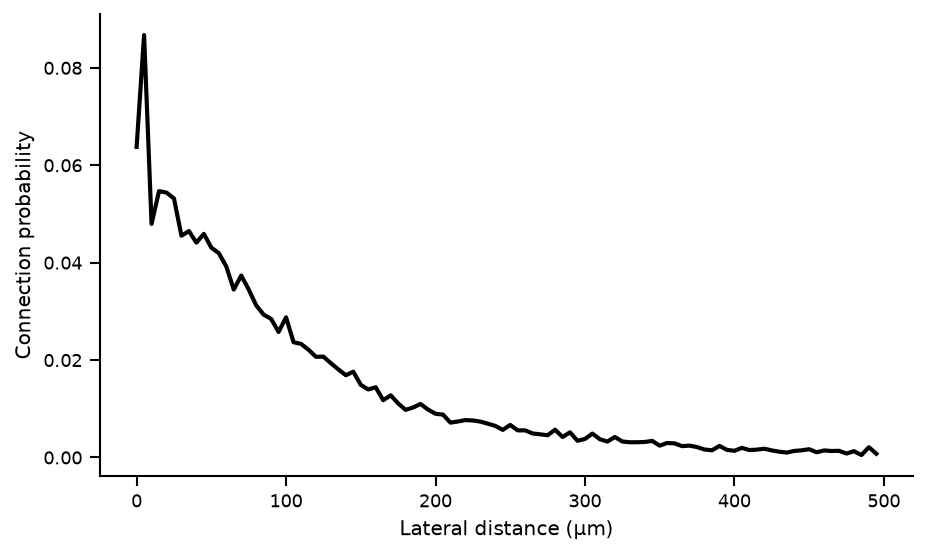

In [ ]:
# Figure 4: Connection probability falls off with lateral distance

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

sns.lineplot(x=bins[:-1], y=connection_probability, lw=2, color="k", ax=ax)

ax.set(xlabel="Lateral distance (µm)", ylabel="Connection probability")
sns.despine()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>To build intuition for what these numbers look like in the volume, here are connected L3-IT pairs at four separations:
<ul>
<li>10 µm: <a href="https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5054147278667776">https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5054147278667776</a>
<li>50 µm: <a href="https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5895810897149952">https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5895810897149952</a>
<li>100 µm: <a href="https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5101346838544384">https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5101346838544384</a>
<li>500 µm: <a href="https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6458760850571264">https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6458760850571264</a>
</ul>

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 7</b> Find the synapse between the 500 µm pair.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2> Part 2: Structure vs. function </h2>
<p><b>Why look for a relationship between connectivity and activity?</b>
<ul>
<li><b>Wiring follows activity.</b> If a synapse strengthens when the two cells it joins tend to fire together — Hebb's rule, and the best-supported mechanism of cortical plasticity — then over the animal's lifetime connections accumulate between cells that respond to similar things.
<li><b>Activity follows wiring.</b> A synapse from A onto B means A's spikes contribute to B's, so a connected pair covaries for no reason other than being connected.
<li><b>Both follow something else.</b> Two neurons receiving input from the same thalamic or cortical afferents are more likely to be co-active <i>and</i>, sitting in the same functional neighbourhood, more likely to be connected.
</ul>
<p>Note: all three predict the same observation — connected pairs are more correlated than unconnected ones — so finding correlation does not distinguish the possible causes.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

We will now use precomputed activity correlations from `cell_cell_correlations_by_stimulus_coregistered.feather` containing the pairwise response correlations between coregistered cells in V1DD.

<p>This analysis is adjacent to <b>like-to-like connectivity</b>: neurons with similar stimulus <i>tuning</i> are more likely, and more strongly, connected (<a href="https://doi.org/10.1038/nature09880">Ko et al., Nature 473:87, 2011</a>; <a href="https://doi.org/10.1038/nature14182">Cossell et al., Nature 518:399, 2015</a>), while the activity correlations we work with are from raw traces, mixing tuning and moment-to-moment co-fluctuation.

<blockquote>
<i>Where these numbers come from</i>
<p>Each value is a <b>Pearson correlation between two ΔF/F traces</b>, computed over the frames belonging to one stimulus condition. The pipeline that produces the table is <a href="../supplement/Functional%20Data%20Cell-Cell%20Correlations.ipynb">Functional Data Cell-Cell Correlations.ipynb</a>: it opens the V1DD two-photon NWB-Zarr sessions, puts every imaging plane on a common timebase, labels each frame with the stimulus on screen, runs <code>np.corrcoef</code> over the frames of each condition, and merges in coregistration to attach EM root ids.
Pearson <i>r</i> is a <b>choice</b>, not the definition of "similar activity". It discards each cell’s baseline and gain, weights every frame equally, and sees only linear relationships. <code>utils/functional_similarity.py</code> generalises that step of the pipeline so the measure becomes an argument, in the same long output format — everything downstream of the table then works unchanged. </blockquote>

</div>

In [ ]:
corr_coreg_df = pd.read_feather(
    f"{functional_dir}/cell_cell_correlations_by_stimulus_coregistered.feather"
)

corr_coreg_df.head(3)

,column,volume,pre_plane,pre_roi,post_plane,post_roi,drifting_gratings_full,drifting_gratings_windowed,locally_sparse_noise,natural_images,natural_images_12,natural_movie,spontaneous,pre_pt_root_id,post_pt_root_id
0,2,5,2,4,2,9,0.038841,-0.033496,0.031585,0.067912,-0.002068,0.101562,0.065001,864691132578859796,864691132784139762
1,2,5,2,4,2,13,0.043010,-0.014050,-0.073923,-0.009737,0.096574,-0.056540,0.000869,864691132578859796,864691132802605719
2,2,5,2,4,2,16,0.434037,0.061785,0.435529,0.220942,0.025282,0.279407,0.215425,864691132578859796,864691132761554538


In [ ]:
# Everything that is not an identifier column is a stimulus condition
stimulus_conditions = corr_coreg_df.columns.drop(
    [
        "pre_pt_root_id",
        "post_pt_root_id",
        "column",
        "volume",
        "pre_plane",
        "pre_roi",
        "post_plane",
        "post_roi",
    ],
    # which metadata columns are present depends on the version of the table
    errors="ignore",
)

stimulus_conditions

Index(['drifting_gratings_full', 'drifting_gratings_windowed',
       'locally_sparse_noise', 'natural_images', 'natural_images_12',
       'natural_movie', 'spontaneous'],
      dtype='object')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>Seven conditions are seven separate measurements, and they need not agree. We choose <code>natural_images</code> for the rest of the module and leave a comparison to the exercises. Naturalistic stimuli drive rich, differentiated population activity, so presumably the correlations are informative.

</div>

In [ ]:
stim = "natural_images"

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Are co-active neurons more likely to be connected? </h3>
<p>Same recipe as Part 1: narrow from all coregistered pairs, to the testable ones, to the connected ones, and see whether the distribution shifts.

</div>

In [ ]:
# Same L3-IT + proofreading restriction as Part 1
corr_coreg_proofread_df = corr_coreg_df[
    np.isin(corr_coreg_df["pre_pt_root_id"], pre_root_ids)
    & np.isin(corr_coreg_df["post_pt_root_id"], post_root_ids)
]

# Pairs that are both coregistered and connected
conn_corr_df = pd.merge(
    conn_df, corr_coreg_proofread_df, on=["pre_pt_root_id", "post_pt_root_id"]
)

print(f"{len(corr_coreg_df):>6,} coregistered pairs")
print(f"{len(corr_coreg_proofread_df):>6,} of those are testable (proofread)")
print(f"{len(conn_corr_df):>6,} of those are connected")

135,622 coregistered pairs
11,286 of those are testable (proofread)
   274 of those are connected


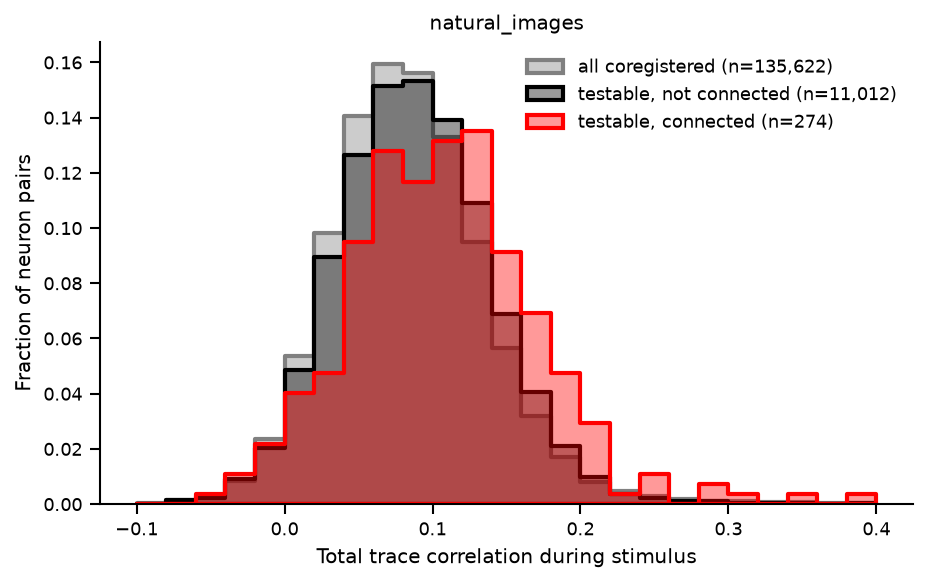

In [ ]:
# Figure 5: Connected pairs are more correlated than the pairs they are drawn from

bins = np.linspace(-0.1, 0.4, 26)

# Split the testable pairs into the two groups every test below compares
unconn_corr_df = corr_coreg_proofread_df[
    ~corr_coreg_proofread_df.index.isin(
        pd.merge(
            corr_coreg_proofread_df.reset_index(),
            conn_df,
            on=["pre_pt_root_id", "post_pt_root_id"],
        )["index"]
    )
]

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

for df, color, label in [
    (corr_coreg_df, "grey", f"all coregistered (n={len(corr_coreg_df):,})"),
    (unconn_corr_df, "k", f"testable, not connected (n={len(unconn_corr_df):,})"),
    (conn_corr_df, "r", f"testable, connected (n={len(conn_corr_df):,})"),
]:
    sns.histplot(
        df,
        x=stim,
        stat="probability",
        bins=bins,
        element="step",
        fill=True,
        alpha=0.4,
        lw=2,
        color=color,
        label=label,
        ax=ax,
    )

ax.legend(frameon=False)
ax.set(
    title=stim,
    xlabel="Total trace correlation during stimulus",
    ylabel="Fraction of neuron pairs",
)
sns.despine()
plt.show()

# Reused in Part 3, so the two figures can be read against each other
correlation_bins = bins
correlation_ylim = ax.get_ylim()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>The red distribution sits to the right of the black one — but only just, and they overlap almost entirely. The same test as in Part 1 says how reliable that shift is, and how big:

</div>

In [ ]:
p, auc = compare_distributions(
    conn_corr_df[stim], unconn_corr_df[stim], "connected", "not connected"
)

connected (n=274)  vs  not connected (n=11,012)
  median          0.1052  vs    0.08662
  p             1.26e-06
  AUC              0.586   (0.5 = indistinguishable)
     a random 'connected' exceeds a random 'not connected' 58.6% of the time


- **Reliable.** $p$ is small, so a shift this size is unlikely to be an accident of sampling.
- **Small.** AUC ≈ 0.58 — barely above the 0.5 of no difference, and nowhere near Part 1's
  distance effect. Given one connected and one unconnected pair, correlation identifies the
  connected one only slightly more often than a coin. You could not use it to predict
  connectivity.

Caveat. Mann–Whitney assumes each sample is made of independent observations. However, the 331 connected pairs come from only 59 presynaptic cells (one of which contributes 21) so pairs sharing a cell carry overlapping information. Dependent samples are more likely to move together by chance, which makes the $p$ assuming independent samples optimistic.

As in Part 1, we can turn this into a connection probability — now as a function of
activity correlation instead of distance. Correlations are not uniformly spread, so we use
**percentile bins**, to put an equal number of cell pairs in each.

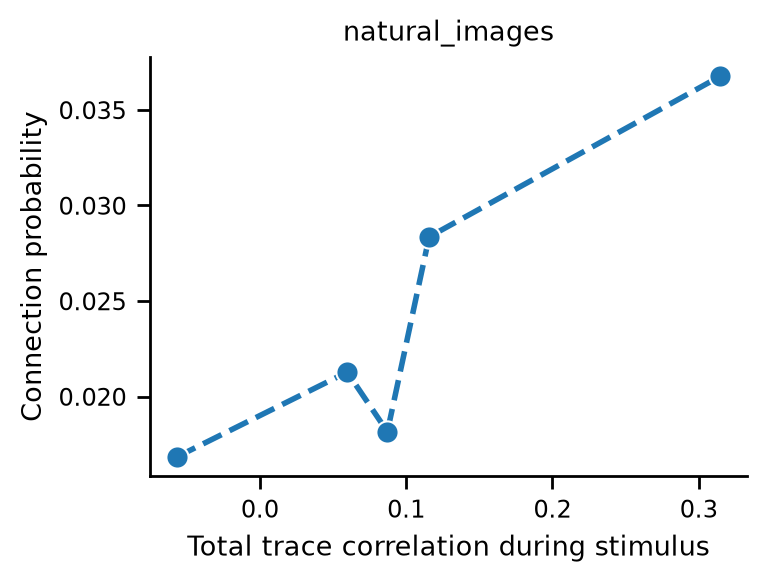

In [ ]:
# Figure 6: Connection probability rises with activity correlation

bins = np.percentile(corr_coreg_proofread_df[stim], np.linspace(0, 100, 6))  # 5 bins
bin_centers = np.convolve(bins, [0.5, 0.5], mode="valid")

proofread_pair_counts = np.histogram(corr_coreg_proofread_df[stim], bins)[0]
connected_pair_counts = np.histogram(conn_corr_df[stim], bins)[0]
connection_probability = connected_pair_counts / proofread_pair_counts

fig, ax = plt.subplots(figsize=(4,3), dpi=200)

sns.lineplot(
    x=bin_centers,
    y=connection_probability,
    lw=2,
    ls="--",
    marker="o",
    markersize=8,
    ax=ax,
)

ax.set(
    title=stim,
    xlabel="Total trace correlation during stimulus",
    ylabel="Connection probability",
)
sns.despine()
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Interim summary </h3>
<p>For L3-IT cells:
<ol>
<li>Neurons closer to each other are more likely to be connected.
<li>Connectivity and co-activity go together: during natural images, connected pairs are more correlated than unconnected ones.
</ol>

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Part 3: A stronger null model — does co-activity carry connectivity information beyond proximity?

We have two results:

1. **Distance → connectivity.** Connected pairs are closer together than unconnected ones
   (AUC 0.19, medians 129 vs 319 µm).
2. **Correlation ↔ connectivity.** Connected pairs are more correlated than unconnected ones
   (AUC 0.58, $p \approx 2 \times 10^{-6}$).

However, they are not independent: **nearby neurons
in visual cortex see similar things.** Their receptive fields overlap, they receive input
from overlapping sets of thalamic and cortical afferents, and they sit in the same
orientation domain. Distance and correlation are therefore linked directly, and connectivity
is linked to both.

That opens a way for (2) to be an artefact of (1):

> Connected pairs are mostly nearby pairs *(result 1)*. Nearby pairs are more correlated
> *(shared input, no wiring involved)*. Therefore connected pairs are more correlated.

Instead of aggregating statistics across distances (as in part 2), here we want to use a null 
model that accounts for the known distance-connectivity relationship.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<i> How would you build such a null model?</i>
<p>Our approach: generate synthetic connectomes in which connection probability depends <i>only</i> on distance — using the curve we measured in Part 1, so the synthetic networks reproduce the real distance dependence exactly — and check whether they also reproduce the observed correlation of connected pairs. If they do, result (2) was proximity in disguise. If the real connectome sits outside the range the synthetic ones cover, something beyond distance is at work.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> One table with everything: distance, activity correlation and connectivity </h3>
<p>We need distance, activity correlation, and connectivity for the same set of pairs. <code>corr_coreg_proofread_df</code> is the most restrictive (coregistration is rare), so we merge onto it.

</div>

In [ ]:
# Base: coregistered, testable L3-IT pairs
full_df = corr_coreg_proofread_df.copy()

# + lateral distance
full_df = pd.merge(
    full_df, lateral_distance_proofread_df, on=["pre_pt_root_id", "post_pt_root_id"]
)

# + connectivity; pairs absent from conn_df are unconnected, i.e. size 0
full_df = pd.merge(
    full_df, conn_df, on=["pre_pt_root_id", "post_pt_root_id"], how="left"
).fillna(0)
full_df["connected"] = full_df["size"] > 0

print(f"{len(full_df):,} pairs, {full_df['connected'].sum():,} connected")
full_df.head(3)

11,286 pairs, 274 connected


,column,volume,pre_plane,pre_roi,post_plane,post_roi,drifting_gratings_full,drifting_gratings_windowed,locally_sparse_noise,natural_images,natural_images_12,natural_movie,spontaneous,pre_pt_root_id,post_pt_root_id,distance,is_connected,size,connected
0,1,3,0,6,0,25,0.011712,-0.018059,0.177509,0.053082,0.118612,0.053856,0.061307,864691132993747701,864691132617961537,91.487462,False,0.0,False
1,1,3,0,6,0,27,0.054421,0.014667,0.100715,0.112722,0.078214,0.030832,0.059752,864691132993747701,864691132758875499,280.750396,False,0.0,False
2,1,3,0,6,0,37,0.046524,0.035209,0.127884,0.123014,0.054419,0.017720,0.062639,864691132993747701,864691132897987302,101.334086,False,0.0,False


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> The measurement to beat </h3>
<p>A null model can only be compared against a single number, so we compress the structure–function result into the mean activity correlation of connected pairs as test statistic.

</div>

In [ ]:
full_df.groupby("connected")[stim].mean()

connected
False    0.088807
True     0.106711
Name: natural_images, dtype: float32

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3> Sampling distance-matched connectomes </h3>
<p>Every pair gets a connection probability from its distance, reusing the Part 1 measurement.

</div>

In [ ]:
distance_bins = np.linspace(0, 500, 101)

proofread_pair_counts = np.histogram(
    lateral_distance_proofread_df["distance"], distance_bins
)[0]
connected_pair_counts = np.histogram(conn_dist_df["distance"], distance_bins)[0]

connection_probability_df = pd.DataFrame(
    {
        "bin_id": np.arange(len(distance_bins) - 1),
        "bin_start": distance_bins[:-1],
        "bin_end": distance_bins[1:],
        "connection_probability": connected_pair_counts / proofread_pair_counts,
    }
)

# np.digitize assigns each pair to a distance bin, which we then join to the per-bin probabilities (-1 for 0-based numbering).
full_df["bin_id"] = np.digitize(full_df["distance"], distance_bins) - 1
full_df = pd.merge(full_df, connection_probability_df, on="bin_id")

print(f"{len(full_df):,} pairs within {distance_bins[-1]:.0f} µm")
connection_probability_df.head(3)

11,286 pairs within 500 µm


,bin_id,bin_start,bin_end,connection_probability
0,0,0.0,5.0,0.063745
1,1,5.0,10.0,0.086713
2,2,10.0,15.0,0.047945


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 8</b> Sample one connectome. Use <a href="https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html"><code>np.random.choice</code></a>, which takes the entries to sample from (<code>a</code>), their probabilities (<code>p</code>, must sum to 1), and how many to draw (<code>size</code>). Draw as many connections as we actually observe.

</div>

In [ ]:
full_sampled_df = full_df.copy()
sampled_idx = np.random.choice(a=, size=, replace=, p=)

full_sampled_df["connected_sampled"] = False
full_sampled_df.loc[sampled_idx, "connected_sampled"] = True

full_sampled_df.groupby("connected_sampled")[stim].mean()

SyntaxError: expected argument value expression (1356848723.py, line 2)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>One sample is noise. Repeating it 10,000 times gives the null <i>distribution</i> of the mean correlation of connected pairs.

</div>

In [ ]:
sampled_means = []

for _ in tqdm.tqdm(range(10_000), mininterval=2.0):
    sampled_idx = np.random.choice(
        full_df.index,
        p=full_df["connection_probability"] / full_df["connection_probability"].sum(),
        size=int(full_df["connected"].sum()),
    )
    sampled_means.append(full_df.loc[sampled_idx, stim].mean())

sampled_means = np.array(sampled_means)  # one entry per sampled connectome
sampled_means[:3]

Because we built the null distribution by sampling rather than from a formula, we can read
the $p$-value straight off it — no distributional assumption at all. Counting how many
synthetic connectomes were at least as extreme as the real one *is* evaluating
$\Pr(T \ge t_{\text{obs}} \mid H_0)$:

$$\hat p \;=\; \frac{1 + \#\{b : T_b \ge t_{\text{obs}}\}}{1 + B}$$

for $B$ samples. The $+1$ s matter: without them a result more extreme than all $B$ samples
reports $\hat p = 0$, claiming infinite confidence from finite sampling. With them the
smallest value reportable from 10,000 samples is $1/10{,}001 \approx 10^{-4}$, which is an
honest floor.
*(Phipson & Smyth, [Stat. Appl. Genet. Mol. Biol. 9:39, 2010](https://doi.org/10.2202/1544-6115.1585).)*

A **Z-score** is the complementary summary. The 10,000 synthetic connectomes give a cloud of
possible values for our statistic — the mean correlation of connected pairs — with a centre
and a width. The Z-score measures how far the *real* connectome's value sits from that
centre, in units of that width:

$$Z \;=\; \frac{t_{\text{obs}} - \operatorname{mean}(T_{\text{null}})}{\operatorname{sd}(T_{\text{null}})}$$

So $Z = 3$ means the real connectome landed three null standard deviations above the typical
synthetic one. It answers the same question as $\hat p$ in a different currency, and it has
one practical advantage: $\hat p$ bottoms out at $1/(B+1)$ once *no* synthetic connectome
reaches the observed value, whereas $Z$ keeps growing and so can still tell a marginal result
from an overwhelming one.

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<p><b>Task 9</b> Compute both, from <code>sampled_means.mean()</code> and <code>sampled_means.std()</code>.

</div>

In [ ]:
observed_mean = full_df[full_df["connected"]][stim].mean()

# zscore = ...
# p_empirical = ...

In [ ]:
# Figure 7: the observed shift (top) against the distance-matched null of the mean (bottom)

connected_mean = conn_corr_df[stim].mean()
unconnected_mean = unconn_corr_df[stim].mean()
zscore = (connected_mean - sampled_means.mean()) / sampled_means.std()

fig, (ax_pairs, ax_null) = plt.subplots(
    2, 1, figsize=(7.5, 5.5), dpi=150, sharex=True, height_ratios=[1, 1]
)

# Top: individual pairs, as in Figure 5
for df, color, label in [
    (unconn_corr_df, "grey", "testable, not connected"),
    (conn_corr_df, "lightcoral", "testable, connected"),
]:
    sns.histplot(
        df,
        x=stim,
        stat="probability",
        bins=correlation_bins,
        element="step",
        fill=True,
        alpha=0.35,
        lw=1.5,
        color=color,
        label=label,
        ax=ax_pairs,
    )
ax_pairs.set_ylim(correlation_ylim)

# Bottom: the null distribution of the mean
sns.histplot(
    x=sampled_means,
    stat="percent",
    bins=51,
    element="step",
    fill=True,
    alpha=0.4,
    lw=2,
    color="k",
    label="distance-matched null\n(mean of each sampled connectome)",
    ax=ax_null,
)

# The same two means, drawn in both panels; labelled once, in the top panel
for ax, label in [(ax_pairs, True), (ax_null, False)]:
    ax.axvline(
        connected_mean,
        color="r",
        ls="--",
        lw=2,
        label="mean: connected" if label else None,
    )
    ax.axvline(
        unconnected_mean,
        color="b",
        ls="--",
        lw=2,
        label="mean: not connected" if label else None,
    )
    ax.legend(frameon=False, fontsize=8, loc="upper right")

ax_null.text(
    0.02,
    0.95,
    f"Z = {zscore:.2f}\np = {p_empirical:.2g}",
    transform=ax_null.transAxes,
    va="top",
)

ax_pairs.set(title=f"{stim}: individual pairs", ylabel="Fraction of neuron pairs")
ax_null.set(
    title="Mean over connected pairs, real vs. distance-matched",
    xlabel="Total trace correlation during stimulus",
    ylabel="Percent of null samples",
)
sns.despine()
plt.tight_layout()
plt.show()

The null reproduces the measured distance dependence exactly, so the surviving effect is not
proximity. Distance alone accounts for most of the correlation seen between connected pairs but not all: The null distribution sits below the observed value, short of it by about four
standard deviations.

<i> Other ways to control for distance:
Stratify by distance (compute statistics over narrow distance bins), logistic regression with distance as a covariate, or shuffle correlations within distance bins. </i>

## Summary

For L3-IT cells in V1DD:

1. **Distance predicts connectivity.** Connection probability falls steeply with lateral
   separation between somas.
2. **Activity correlation and connectivity are associated.** During natural images, connected pairs
   are more correlated than testable pairs overall.
3. **The second is not just the first.** A null model that reproduces the distance
   dependence exactly still does not reproduce the correlation of connected pairs
   (Z ≈ 4.2, $\hat p \sim 10^{-4}$). Co-activity carries information about connectivity beyond proximity, such as shared input.

Read the effect sizes next to the $p$-values, because they tell different stories. Both
comparisons return an overwhelming $p$, but distance is a *large* effect — AUC ≈ 0.19, so of
a connected and an unconnected pair the connected one is the closer about four times in five
— while correlation is *reliable but small*: AUC ≈ 0.58, barely above the 0.5 of no
difference. Correlation could not be used to predict connectivity even though its mean shift
is firmly established.

Three habits worth carrying into a project:

- **Restrict to what you can measure.** Every comparison above is against *proofread*
  pairs, not all pairs.
- **Name your null model.** Part 3 changes it from the implicit "uniform across distance" to "distance-matched" connection probability.
- **Separate reliable from large.** A p-value or Z-score addresses *is this real*. An effect
  size addresses *does it matter*.